<a href="https://colab.research.google.com/github/fitrihayatii02-cloud/Praktikum-ADW---Fitri-Hayati-M0501251043-/blob/main/Tugas_Kelompok_STA2542_Minggu_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>

---
Anggota Kelompok 1:
1. Chindy Putri Army (M0501251024)
2. Fitri Hayati (M0501251043)
3. Nadhira Maulida Hayani (M0501261093)

---

##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

Pengumpulan hasil diskusi:

- melalui class.ipb.ac.id cukup perwakilan kelompok dengan format pdf. Dalam file tersebut memuat identitas anggota kelompok (Nama, NIM). Dalam file tidak perlu mencantumkan sintaks, namun menampilkan plot deret waktu dari deret simulasi dan interpretasinya; pembagian data latih data uji dan alasan pemilihan pembagian data; plot ACF, PACF, EACF, dan interpretasinya; hasil pengepasan model dan diagnostik sisaan model dan interpretasinya; plot hasil peramalan dan deret asli, nilai metrik evaluasi, dan interpretasinya.

- melalui github masing-masing anggota kelompok berupa file sintaks.

# **MA(1) deret parameter $\theta=0.6$ dan panjang amatan 120.**

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox, boxcox_llf
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(160)
ar1 = np.array([1])
ma1_theta_06 = np.array([1, -0.6]) #nilai parameter theta dalam sintaks dituliskan sebagai negatif dari nilai parameter asli, misal parameter asli 0.1 dalam sintaks ditulis -0.1
ma_object1_theta_06 = ArmaProcess(ar1,ma1_theta_06)
ma1_theta_06= ma_object1_theta_06.generate_sample(nsample=120)
print(ma1_theta_06)

[-0.4967794   1.23609211 -2.069445   -0.0319759   2.33011126 -0.46809116
 -0.75024399 -0.9401281   1.7776401  -1.54639203 -0.05639032  0.22885898
 -1.92749271  3.47887405 -1.53240318 -1.52891926  1.00226994  0.47039572
  0.01901455  1.19457302 -2.14830063  2.44188014  0.90656837 -0.20821909
 -0.73402979 -1.17438292  0.62316379  1.19707103 -1.78759667  1.12851971
 -0.60179667 -1.54658969  1.88910177  0.41327238 -1.24283312  0.54732139
 -0.84337826  1.65727307 -1.77794171 -0.44259627  0.66665228  0.32971011
  1.31190092 -1.22000307  1.00536088 -0.58466569  0.12624381  0.46465398
 -1.33936498  1.07092524 -0.6627819  -0.28029855  0.72303003 -1.23856128
 -0.36900977  0.26558302  1.75709638 -2.55418366  2.91618524 -0.28713863
 -0.40536919  0.38830899  0.20389363  1.29367992 -0.13163533 -0.02836741
 -1.02030882 -0.4885615   1.21508404 -1.28258988 -0.15518566  1.51928682
 -0.66926487 -0.63805408 -0.79657831  1.55707916 -0.0115099   0.43223337
  1.17813041 -1.04680563 -0.94769618  1.21587543 -0

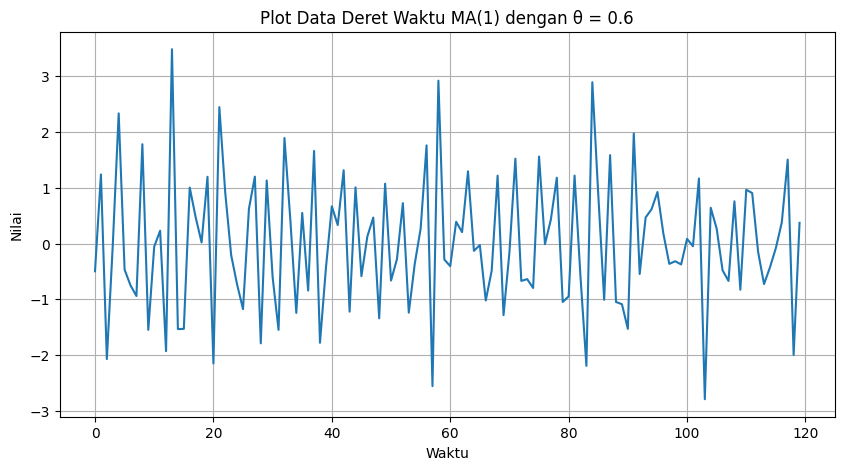

In [ ]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(ma1_theta_06)
plt.title('Plot Data Deret Waktu MA(1) dengan θ = 0.6')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.grid(True)
plt.show()

Berdasarkan plot deret waktu MA(1) dengan θ = 0,6, terlihat bahwa data berfluktuasi di sekitar nilai rata-rata yang relatif konstan dan tidak menunjukkan adanya tren maupun pola musiman yang jelas. Variabilitas data juga relatif stabil sepanjang periode pengamatan, meskipun terdapat beberapa nilai ekstrem. Dengan demikian, secara visual deret waktu menunjukkan karakteristik stasioner sehingga dapat dilanjutkan ke tahap identifikasi model menggunakan ACF, PACF, dan EACF.

2.  Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

Pembagian data dilakukan dengan proporsi 80% data latih dan 20% data uji.

In [ ]:
# Pembagian data training dan testing

size_train = round(0.8 * ma1_theta_06.shape[0])

train, test = ma1_theta_06[:size_train], ma1_theta_06[size_train:]

print("Jumlah data training:", len(train))
print("Jumlah data testing:", len(test))

Jumlah data training: 96
Jumlah data testing: 24


In [ ]:
train[:5]

array([-0.4967794 ,  1.23609211, -2.069445  , -0.0319759 ,  2.33011126])

In [ ]:
test[:5]

array([ 0.17647137, -0.36480641, -0.3177322 , -0.37498024,  0.08338211])

In [ ]:
adfuller(train, autolag='AIC')[1]

/tmp/ipykernel_657/515730907.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller(train, autolag='AIC')[1]


3.531037027569021e-05

Berdasarkan uji Augmented Dickey-Fuller (ADF), diperoleh p-value sebesar 0.00003531 < 0.05, sehingga tolak $H_0$. Sehingga dapat disimpulkan bahwa data latih telah stasioner dalam rataan dan siap digunakan untuk pemodelan.

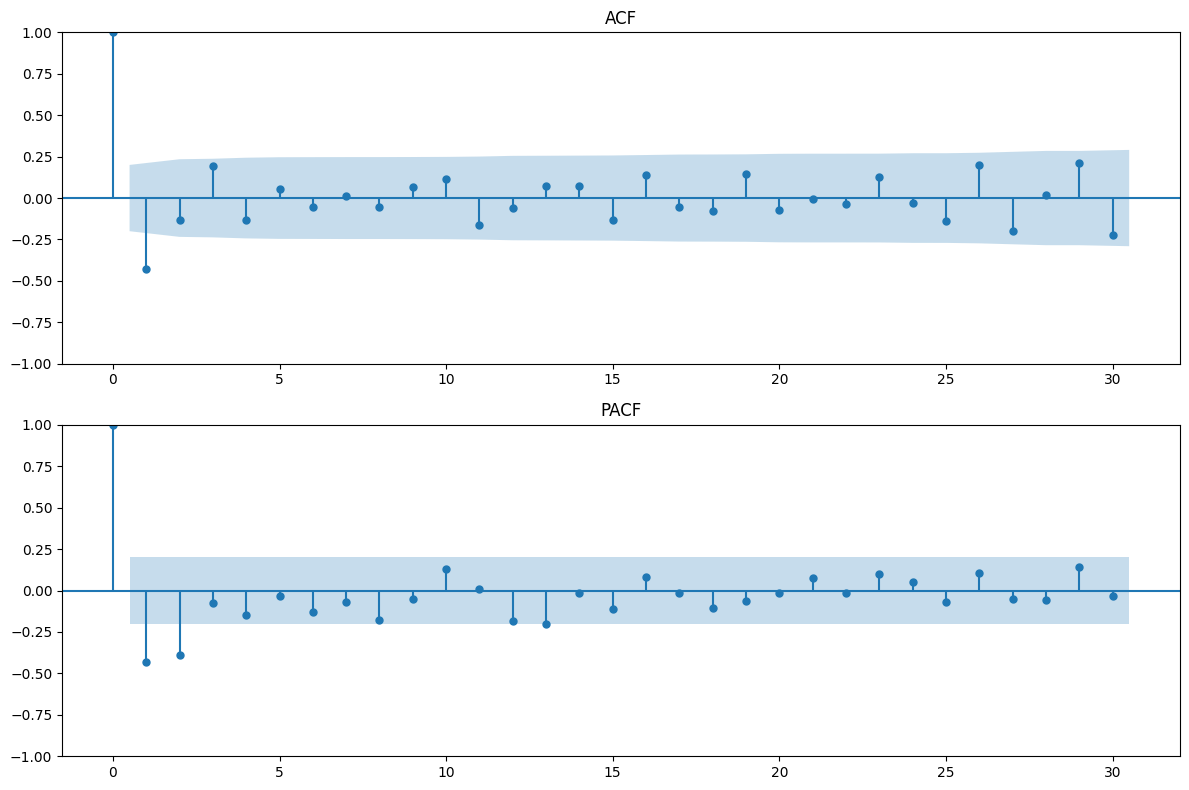

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
# ACF
plot_acf(train, lags=30, ax=ax[0])
ax[0].set_title("ACF")
# PACF
plot_pacf(train, lags=30, ax=ax[1], method='ywm')
ax[1].set_title("PACF")
plt.tight_layout()
plt.show()

Berdasarkan plot ACF, terdapat spike yang signifikan hingga lag 1, sedangkan pada plot PACF terdapat spike yang signifikan hingga lag 2. Pola tersebut mengindikasikan bahwa model tentatif yang dapat digunakan adalah ARMA(2,1). Selanjutnya, model AR(2) dan MA(1) juga digunakan sebagai model pembanding.

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
install.packages("TSA", repos="https://cloud.r-project.org")
library(TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/TSA_1.3.1.tar.gz'
Content type 'application/x-gzip' length 207505 bytes (202 KB)
downloaded 202 KB


The downloaded source packages are in
	‘/tmp/Rtmp0gNStV/downloaded_packages’


In [ ]:
%%R -i train

# Plot EACF dari data training
eacf(as.numeric(train))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x x o o o o o o o o o  o  o  o 
2 x x o o o o o o o o o  o  o  o 
3 x x o o o o o o o o o  o  o  o 
4 x x o o o o o o o o o  o  o  o 
5 x x o o o o o o o o o  o  o  o 
6 x x o o o o o o o o o  o  o  o 
7 x x o o o o o o o o o  o  o  o 


Berdasarkan plot EACF, pola segitiga yang terbentuk dari simbol **o** menunjukkan MA(2) sebagai salah satu kandidat model. Dengan mempertimbangkan hasil identifikasi ACF, PACF, dan EACF, diperoleh empat kandidat model, yaitu **ARMA(2,1), AR(2), MA(1), dan MA(2)**.

Selanjutnya, dilakukan diagnostik residual, pengecekan overfitting, serta perbandingan AIC dan BIC untuk menentukan model yang paling sesuai.

**Model MA(1)**

In [ ]:
#model MA (1)
train_ma1=ARIMA(train,order=(0,0,1)).fit()

In [ ]:
print(train_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -137.584
Date:                Wed, 23 Sep 2026   AIC                            281.168
Time:                        04:33:50   BIC                            288.861
Sample:                             0   HQIC                           284.277
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0290      0.016      1.868      0.062      -0.001       0.059
ma.L1         -0.8625      0.058    -14.930      0.000      -0.976      -0.749
sigma2         1.0143      0.173      5.851      0.0

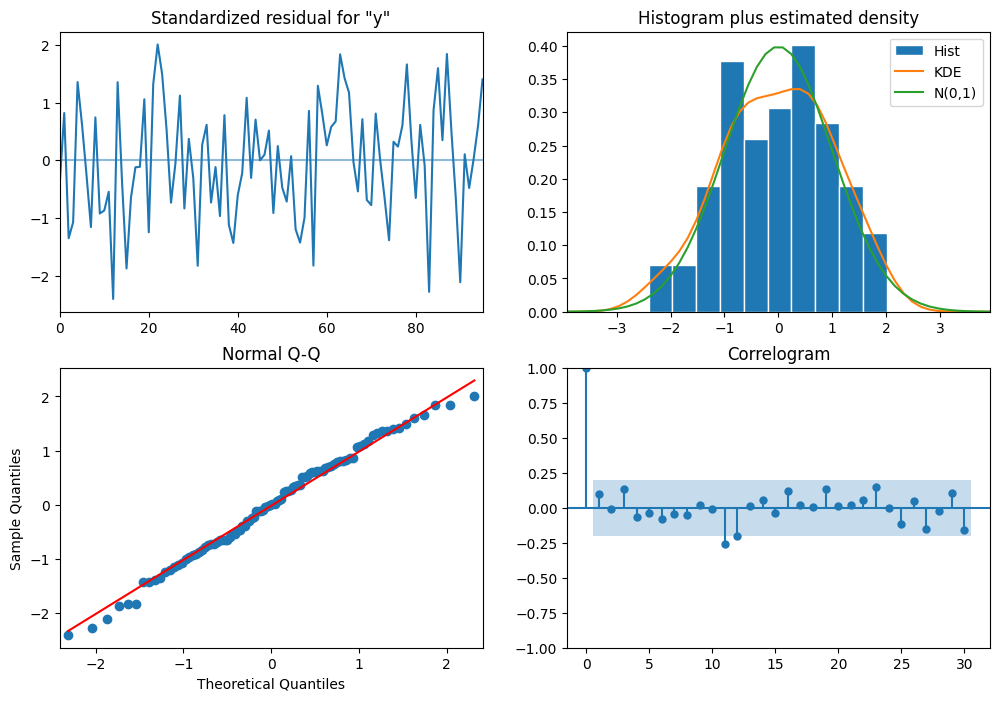

In [ ]:
train_ma1.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(train_ma1.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.6838990762915085)

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(train_ma1.resid, correction=False)

(np.float64(-0.6116142535705553), np.float64(0.5407930053783456))

In [ ]:
from scipy.stats import shapiro
stat,p = shapiro(train_ma1.resid)
print(stat,p)

0.9872312224370287 0.4834022559284504


## Interpretasi Model MA(1) dan Diagnostik Residual

Berdasarkan hasil estimasi model, diperoleh model **MA(1)** dengan persamaan:

$$
Y_t = 0.0290 - 0.8625\varepsilon_{t-1} + \varepsilon_t
$$

Konstanta sebesar **0.0290** memiliki p-value **0.062 > 0.05**, sehingga konstanta tidak signifikan pada taraf signifikansi 5%. Parameter **MA(1)** sebesar **-0.8625** memiliki p-value **0.000 < 0.05**, sehingga parameter MA(1) dinyatakan signifikan.

Model MA(1) memiliki nilai **AIC sebesar 281.168** dan **BIC sebesar 288.861**. Nilai tersebut akan digunakan untuk membandingkan model MA(1) dengan model kandidat lainnya.

### Diagnostik Residual

**1. Uji Ljung-Box**

Uji Ljung-Box digunakan untuk mengetahui apakah residual telah bersifat *white noise*. Diperoleh p-value sebesar **0.32 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada residual dan residual model MA(1) dapat dianggap telah bersifat **white noise**.

**2. Uji Jarque-Bera**

Uji Jarque-Bera digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh p-value sebesar **0.44 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga residual dapat dianggap **berdistribusi normal**. Hasil ini juga didukung oleh plot **Normal Q-Q**, di mana sebagian besar titik residual berada di sekitar garis diagonal.

**3. Uji Heteroskedastisitas**

Uji heteroskedastisitas digunakan untuk mengetahui apakah varians residual bersifat konstan. Diperoleh p-value sebesar **0.61 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap **homogen (konstan)**.

### Uji Diagnostik Tambahan

**4. Uji ARCH-LM**

Uji ARCH-LM digunakan untuk mengetahui ada atau tidaknya efek ARCH pada residual. Diperoleh p-value sebesar **0.6839 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, **tidak terdapat efek ARCH** pada residual dan varians residual dapat dianggap **konstan**.

**5. Uji Runs**

Uji Runs digunakan untuk mengetahui apakah residual bersifat acak (*random*). Diperoleh p-value sebesar **0.5408 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **bersifat acak**.

**6. Uji Shapiro-Wilk**

Uji Shapiro-Wilk digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh statistik uji sebesar **0.9872** dengan p-value sebesar **0.4834 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **berdistribusi normal**.

### Kesimpulan Model MA(1)

Berdasarkan hasil estimasi, parameter **MA(1) signifikan**, sedangkan konstanta tidak signifikan. Hasil diagnostik residual menunjukkan bahwa residual telah memenuhi asumsi **white noise, normalitas, homoskedastisitas, tidak terdapat efek ARCH, dan bersifat acak**.

Dengan demikian, model **MA(1) layak digunakan sebagai salah satu kandidat model**. Selanjutnya, model MA(1) dibandingkan dengan model **AR(2), MA(2), dan ARMA(2,1)** berdasarkan signifikansi parameter, nilai **AIC dan BIC**, serta hasil diagnostik residual untuk menentukan model yang paling sesuai.

model MA(2)

In [ ]:
train_ma2=ARIMA(train,order=(0,0,2)).fit()

In [ ]:
print(train_ma2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -136.671
Date:                Wed, 23 Sep 2026   AIC                            281.341
Time:                        04:33:51   BIC                            291.599
Sample:                             0   HQIC                           285.488
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0297      0.011      2.744      0.006       0.008       0.051
ma.L1         -0.7631      0.102     -7.485      0.000      -0.963      -0.563
ma.L2         -0.1510      0.096     -1.573      0.1

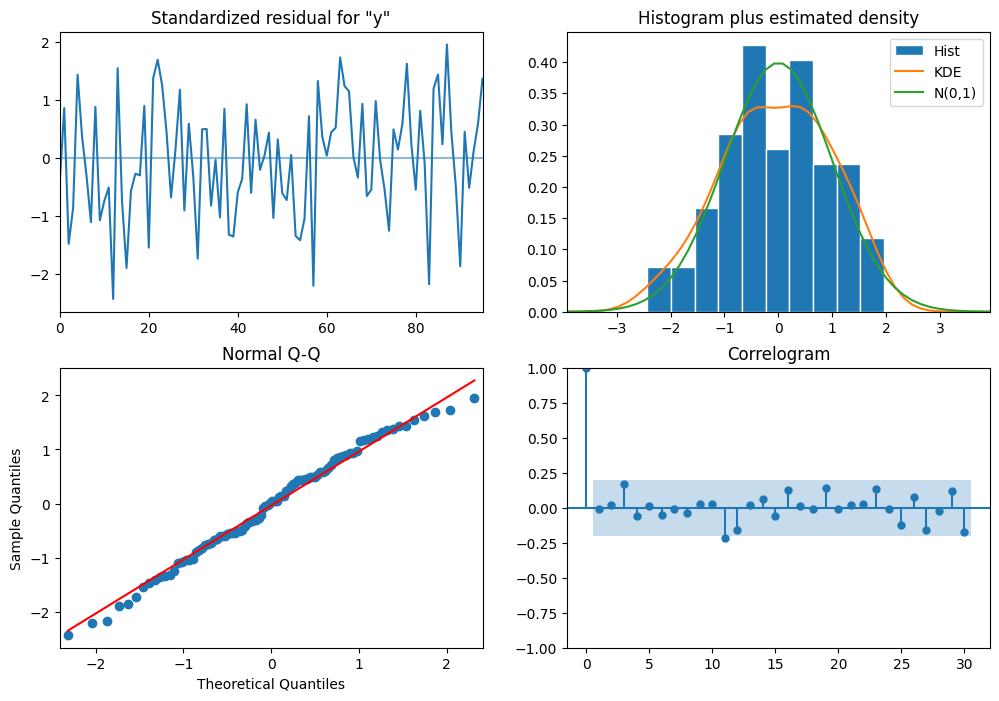

In [ ]:
train_ma2.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
het_arch(train_ma2.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.7296151663176471)

In [ ]:
runstest_1samp(train_ma2.resid, correction=False)

(np.float64(0.24464918716196088), np.float64(0.806728075242825))

In [ ]:
stat,p = shapiro(train_ma2.resid)
print(stat,p)

0.9850018255429414 0.3453850613579379


## Interpretasi Model MA(2) dan Diagnostik Residual

Berdasarkan hasil estimasi model, diperoleh model **MA(2)** dengan persamaan:

$$
Y_t = 0.0297 - 0.7631\varepsilon_{t-1}
- 0.1510\varepsilon_{t-2} + \varepsilon_t
$$

Konstanta sebesar **0.0297** memiliki p-value **0.006 < 0.05**, sehingga konstanta signifikan pada taraf signifikansi 5%. Parameter **MA(1)** sebesar **-0.7631** memiliki p-value **0.000 < 0.05**, sehingga parameter MA(1) signifikan. Sementara itu, parameter **MA(2)** sebesar **-0.1510** memiliki p-value **0.116 > 0.05**, sehingga parameter MA(2) tidak signifikan.

Model MA(2) memiliki nilai **AIC sebesar 281.341** dan **BIC sebesar 291.599**. Nilai AIC dan BIC selanjutnya digunakan untuk membandingkan model MA(2) dengan model kandidat lainnya.

### Diagnostik Residual

**1. Uji Ljung-Box**

Uji Ljung-Box digunakan untuk mengetahui apakah residual telah bersifat *white noise*. Diperoleh p-value sebesar **0.96 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada residual dan residual model MA(2) dapat dianggap telah bersifat **white noise**.

**2. Uji Jarque-Bera**

Uji Jarque-Bera digunakan untuk menguji normalitas residual. Diperoleh p-value sebesar **0.36 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak normal, sehingga residual dapat dianggap **berdistribusi normal**. Hasil ini juga didukung oleh plot **Normal Q-Q**, di mana sebagian besar titik berada di sekitar garis diagonal.

**3. Uji Heteroskedastisitas**

Uji heteroskedastisitas digunakan untuk mengetahui apakah varians residual bersifat konstan. Diperoleh p-value sebesar **0.49 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap **homogen (konstan)**.

**4. Uji ARCH-LM**

Uji ARCH-LM digunakan untuk mengetahui ada atau tidaknya efek ARCH pada residual. Diperoleh p-value sebesar **0.7296 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, **tidak terdapat efek ARCH** pada residual dan varians residual dapat dianggap **konstan**.

**5. Uji Runs**

Uji Runs digunakan untuk mengetahui apakah residual bersifat acak (*random*). Diperoleh p-value sebesar **0.8067 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **bersifat acak**.

**6. Uji Shapiro-Wilk**

Uji Shapiro-Wilk digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh statistik uji sebesar **0.9850** dengan p-value sebesar **0.3454 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **berdistribusi normal**.

### Kesimpulan

Berdasarkan hasil estimasi dan diagnostik residual, model MA(2) memiliki parameter MA(1) yang signifikan, sedangkan parameter MA(2) tidak signifikan. Meskipun parameter MA(2) tidak signifikan, hasil uji diagnostik menunjukkan bahwa residual telah memenuhi asumsi **white noise, normalitas, homoskedastisitas, tidak terdapat efek ARCH, dan bersifat acak**.

Dengan demikian, model **MA(2) layak digunakan sebagai salah satu kandidat model**. Selanjutnya, model MA(2) akan dibandingkan dengan **MA(1), AR(2), dan ARMA(2,1)** berdasarkan signifikansi parameter, nilai **AIC dan BIC**, serta hasil diagnostik residual untuk menentukan model yang paling sesuai.

model ARMA(2,1)

In [ ]:
train_arma21=ARIMA(train,order=(2,0,1)).fit()

In [ ]:
print(train_arma21.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -136.540
Date:                Wed, 23 Sep 2026   AIC                            283.080
Time:                        04:33:52   BIC                            295.901
Sample:                             0   HQIC                           288.262
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0298      0.009      3.303      0.001       0.012       0.048
ar.L1          0.1810      0.112      1.609      0.108      -0.039       0.401
ar.L2          0.0491      0.118      0.415      0.6

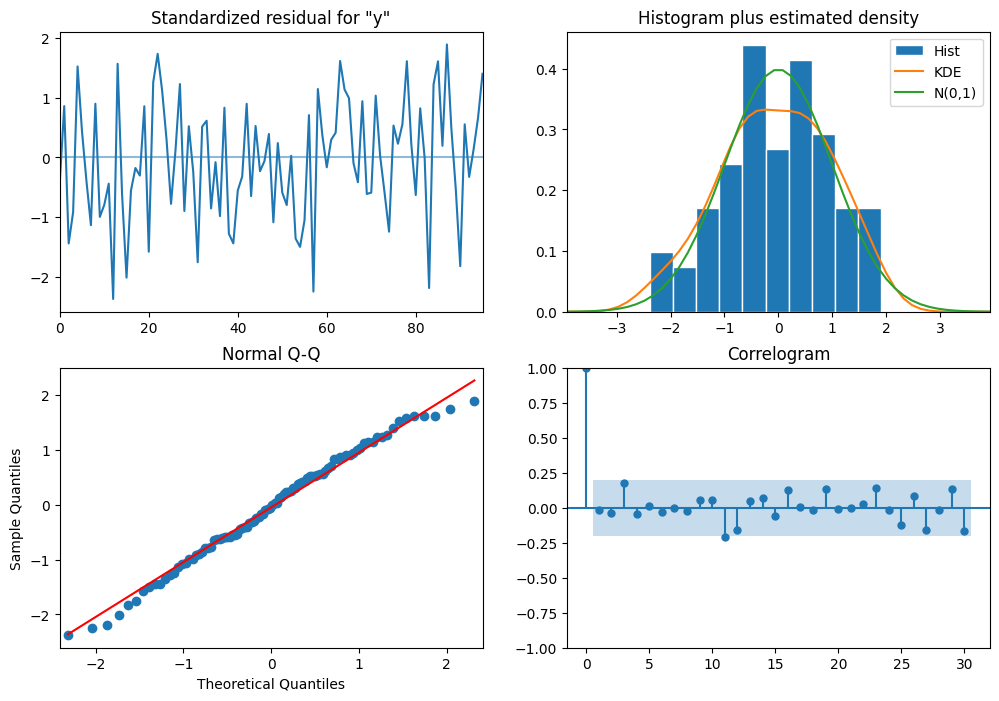

In [ ]:
train_arma21.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
het_arch(train_arma21.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.7772706145325435)

In [ ]:
runstest_1samp(train_arma21.resid, correction=False)

(np.float64(0.2052070395430288), np.float64(0.8374103697213153))

In [ ]:
stat,p = shapiro(train_arma21.resid)
print(stat,p)

0.984548983631447 0.32144896517831917


## Interpretasi Model ARMA(2,1) dan Diagnostik Residual

Berdasarkan hasil estimasi model, diperoleh model **ARMA(2,1)** dengan persamaan:

$$
Y_t = 0.0298 + 0.1810Y_{t-1} + 0.0491Y_{t-2}
- 0.9523\varepsilon_{t-1} + \varepsilon_t
$$

Konstanta sebesar **0.0298** memiliki p-value **0.001 < 0.05**, sehingga konstanta dinyatakan signifikan pada taraf signifikansi 5%.

Parameter **AR(1)** sebesar **0.1810** memiliki p-value **0.108 > 0.05**, sehingga parameter AR(1) tidak signifikan. Parameter **AR(2)** sebesar **0.0491** memiliki p-value **0.678 > 0.05**, sehingga parameter AR(2) juga tidak signifikan.

Sementara itu, parameter **MA(1)** sebesar **-0.9523** memiliki p-value **0.000 < 0.05**, sehingga parameter MA(1) dinyatakan signifikan.

Model ARMA(2,1) memiliki nilai **AIC sebesar 283.080** dan **BIC sebesar 295.901**. Nilai tersebut selanjutnya digunakan untuk membandingkan model ARMA(2,1) dengan model kandidat lainnya.

### Diagnostik Residual

**1. Uji Ljung-Box**

Uji Ljung-Box digunakan untuk mengetahui apakah residual telah bersifat *white noise*. Diperoleh p-value sebesar **0.88 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada residual dan residual model ARMA(2,1) dapat dianggap telah bersifat **white noise**.

**2. Uji Jarque-Bera**

Uji Jarque-Bera digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh p-value sebesar **0.36 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga residual dapat dianggap **berdistribusi normal**. Hasil ini juga didukung oleh plot **Normal Q-Q**, di mana sebagian besar titik residual berada di sekitar garis diagonal.

**3. Uji Heteroskedastisitas**

Uji heteroskedastisitas digunakan untuk mengetahui apakah varians residual bersifat konstan. Diperoleh p-value sebesar **0.50 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap **homogen (konstan)**.

### Uji Diagnostik Tambahan

**4. Uji ARCH-LM**

Uji ARCH-LM digunakan untuk mengetahui ada atau tidaknya efek ARCH pada residual. Diperoleh p-value sebesar **0.7773 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, **tidak terdapat efek ARCH** pada residual dan varians residual dapat dianggap **konstan**.

**5. Uji Runs**

Uji Runs digunakan untuk mengetahui apakah residual bersifat acak (*random*). Diperoleh p-value sebesar **0.8374 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **bersifat acak**.

**6. Uji Shapiro-Wilk**

Uji Shapiro-Wilk digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh statistik uji sebesar **0.9845** dengan p-value sebesar **0.3214 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **berdistribusi normal**.

### Kesimpulan Model ARMA(2,1)

Berdasarkan hasil estimasi, parameter **MA(1) signifikan**, sedangkan parameter **AR(1) dan AR(2) tidak signifikan**. Hasil diagnostik residual menunjukkan bahwa residual telah memenuhi asumsi **white noise, normalitas, homoskedastisitas, tidak terdapat efek ARCH, dan bersifat acak**.

Dengan demikian, model **ARMA(2,1) layak digunakan sebagai salah satu kandidat model**. Namun, karena parameter AR(1) dan AR(2) tidak signifikan, model ini perlu dibandingkan dengan model yang lebih sederhana, terutama **MA(1)**, berdasarkan nilai **AIC dan BIC**, signifikansi parameter, serta hasil diagnostik residual.

model AR(2)

In [ ]:
train_ar2=ARIMA(train,order=(2,0,0)).fit()

In [ ]:
print(train_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -140.282
Date:                Wed, 23 Sep 2026   AIC                            288.564
Time:                        04:33:53   BIC                            298.821
Sample:                             0   HQIC                           292.710
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0308      0.054      0.566      0.572      -0.076       0.138
ar.L1         -0.6014      0.091     -6.586      0.000      -0.780      -0.422
ar.L2         -0.3928      0.103     -3.796      0.0

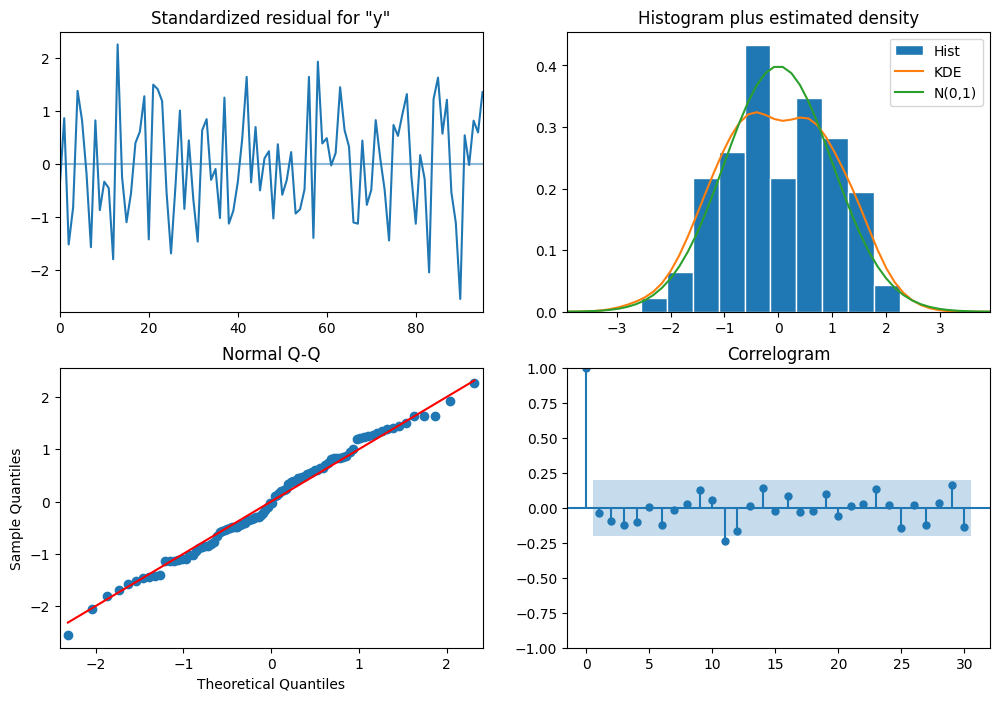

In [ ]:
train_ar2.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [ ]:
het_arch(train_ar2.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.4582981335639688)

In [ ]:
runstest_1samp(train_ar2.resid, correction=False)

(np.float64(0.2095741148598413), np.float64(0.8340000843230427))

In [ ]:
stat,p = shapiro(train_ar2.resid)
print(stat,p)

0.9878113024452084 0.5244372386420013


## Interpretasi Model AR(2) dan Diagnostik Residual

Berdasarkan hasil estimasi model, diperoleh model **AR(2)** dengan persamaan:

$$
Y_t = 0.0308 - 0.6014Y_{t-1} - 0.3928Y_{t-2} + \varepsilon_t
$$

Konstanta sebesar **0.0308** memiliki p-value **0.572 > 0.05**, sehingga konstanta dinyatakan tidak signifikan pada taraf signifikansi 5%.

Parameter **AR(1)** sebesar **-0.6014** memiliki p-value **0.000 < 0.05**, sehingga parameter AR(1) dinyatakan signifikan. Parameter **AR(2)** sebesar **-0.3928** juga memiliki p-value **0.000 < 0.05**, sehingga parameter AR(2) dinyatakan signifikan.

Model AR(2) memiliki nilai **AIC sebesar 288.564** dan **BIC sebesar 298.821**. Nilai tersebut selanjutnya digunakan untuk membandingkan model AR(2) dengan model kandidat lainnya.

### Diagnostik Residual

**1. Uji Ljung-Box**

Uji Ljung-Box digunakan untuk mengetahui apakah residual telah bersifat *white noise*. Diperoleh p-value sebesar **0.69 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada residual dan residual model AR(2) dapat dianggap telah bersifat **white noise**.

**2. Uji Jarque-Bera**

Uji Jarque-Bera digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh p-value sebesar **0.43 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga residual dapat dianggap **berdistribusi normal**.

**3. Uji Heteroskedastisitas**

Uji heteroskedastisitas digunakan untuk mengetahui apakah varians residual bersifat konstan. Diperoleh p-value sebesar **0.69 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap **homogen (konstan)**.

### Uji Diagnostik Tambahan

**4. Uji ARCH-LM**

Uji ARCH-LM digunakan untuk mengetahui ada atau tidaknya efek ARCH pada residual. Diperoleh p-value sebesar **0.4583 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, **tidak terdapat efek ARCH** pada residual dan varians residual dapat dianggap **konstan**.

**5. Uji Runs**

Uji Runs digunakan untuk mengetahui apakah residual bersifat acak (*random*). Diperoleh p-value sebesar **0.8340 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **bersifat acak**.

**6. Uji Shapiro-Wilk**

Uji Shapiro-Wilk digunakan untuk menguji apakah residual berdistribusi normal. Diperoleh statistik uji sebesar **0.9878** dengan p-value sebesar **0.5244 > 0.05**, sehingga H₀ tidak ditolak. Dengan demikian, residual dapat dianggap **berdistribusi normal**.

### Kesimpulan Model AR(2)

Berdasarkan hasil estimasi, parameter **AR(1) dan AR(2) signifikan**, sedangkan konstanta tidak signifikan. Hasil diagnostik residual menunjukkan bahwa residual telah memenuhi asumsi **white noise, normalitas, homoskedastisitas, tidak terdapat efek ARCH, dan bersifat acak**.

Dengan demikian, model **AR(2) layak digunakan sebagai salah satu kandidat model**. Selanjutnya, model AR(2) dibandingkan dengan **MA(1), MA(2), dan ARMA(2,1)** berdasarkan signifikansi parameter, nilai **AIC dan BIC**, serta hasil diagnostik residual untuk menentukan model yang paling sesuai.

**Perbandingan model secara keseluruhan**

In [ ]:
import pandas as pd

models = {
    'MA(1)': train_ma1,
    'MA(2)': train_ma2,
    'ARMA(2,1)': train_arma21,
    'AR(2)': train_ar2
}

hasil_parameter = []

for nama_model, model in models.items():
    for param, nilai, pvalue in zip(
        model.param_names,
        model.params,
        model.pvalues
    ):

        # Lewati konstanta
        if param == 'const':
            continue

        hasil_parameter.append({
            'Model': nama_model,
            'Parameter': param,
            'Estimasi': round(nilai, 4),
            'p-value': round(pvalue, 4),
            'Signifikansi': 'Signifikan' if pvalue < 0.05 else 'Tidak signifikan',
            'AIC': round(model.aic, 4),
            'BIC': round(model.bic, 4)
        })

hasil_parameter = pd.DataFrame(hasil_parameter)

print(hasil_parameter.to_string(index=False))

    Model Parameter  Estimasi  p-value     Signifikansi      AIC      BIC
    MA(1)     ma.L1   -0.8625   0.0000       Signifikan 281.1676 288.8607
    MA(1)    sigma2    1.0143   0.0000       Signifikan 281.1676 288.8607
    MA(2)     ma.L1   -0.7631   0.0000       Signifikan 281.3413 291.5987
    MA(2)     ma.L2   -0.1510   0.1158 Tidak signifikan 281.3413 291.5987
    MA(2)    sigma2    0.9918   0.0000       Signifikan 281.3413 291.5987
ARMA(2,1)     ar.L1    0.1810   0.1076 Tidak signifikan 283.0797 295.9015
ARMA(2,1)     ar.L2    0.0491   0.6782 Tidak signifikan 283.0797 295.9015
ARMA(2,1)     ma.L1   -0.9523   0.0000       Signifikan 283.0797 295.9015
ARMA(2,1)    sigma2    0.9867   0.0000       Signifikan 283.0797 295.9015
    AR(2)     ar.L1   -0.6014   0.0000       Signifikan 288.5635 298.8209
    AR(2)     ar.L2   -0.3928   0.0001       Signifikan 288.5635 298.8209
    AR(2)    sigma2    1.0822   0.0000       Signifikan 288.5635 298.8209


### Pemilihan Model

Berdasarkan tabel hasil estimasi, model yang seluruh parameternya signifikan adalah **MA(1)** dan **AR(2)**. Model **MA(1)** memiliki nilai AIC sebesar **281.1676** dan BIC sebesar **288.8607**, sedangkan model **AR(2)** memiliki AIC sebesar **288.5635** dan BIC sebesar **298.8209**. Karena model MA(1) memiliki nilai AIC dan BIC yang lebih kecil, maka MA(1) dipilih sebagai model yang lebih sesuai berdasarkan kriteria tersebut.

Selanjutnya dilakukan **overfitting** terhadap model MA(1) dengan mencoba model **MA(2)**. Hasil estimasi menunjukkan bahwa parameter MA(2) pada lag kedua tidak signifikan (p-value = 0.1158), serta nilai AIC sebesar **281.3413** dan BIC sebesar **291.5987** lebih besar dibandingkan MA(1).

Dengan demikian, **model MA(1) ditetapkan sebagai model terbaik** di antara model kandidat yang telah diuji karena memiliki seluruh parameter yang signifikan serta nilai AIC dan BIC yang paling kecil.

**Pengujian model terbaik MA(1)**

In [ ]:
prediksi_test=train_ma1.get_forecast(test.shape[0]).summary_frame(alpha=0.05)

In [ ]:
prediksi_test

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,-1.187972,1.007148,-3.161946,0.786001
1,0.029011,1.330031,-2.577801,2.635823
2,0.029011,1.330031,-2.577801,2.635823
3,0.029011,1.330031,-2.577801,2.635823
4,0.029011,1.330031,-2.577801,2.635823
5,0.029011,1.330031,-2.577801,2.635823
6,0.029011,1.330031,-2.577801,2.635823
7,0.029011,1.330031,-2.577801,2.635823
8,0.029011,1.330031,-2.577801,2.635823
9,0.029011,1.330031,-2.577801,2.635823


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
# Fitted value untuk training
forecast_train = train_ma1.fittedvalues

# Forecast untuk testing
forecast_test = train_ma1.forecast(steps=len(test))

# Gabungkan forecast training + testing
forecast_all = np.concatenate([forecast_train, forecast_test])

# Gabungkan data aktual training + testing
actual_all = np.concatenate([train, test])

# =========================
# EVALUASI
# =========================

# MAPE training
mape_train = mean_absolute_percentage_error(
    train, forecast_train
) * 100

# MAPE testing
mape_test = mean_absolute_percentage_error(
    test, forecast_test
) * 100

# RMSE training
rmse_train = np.sqrt(
    mean_squared_error(train, forecast_train)
)

# RMSE testing
rmse_test = np.sqrt(
    mean_squared_error(test, forecast_test)
)

# Tampilkan hasil
hasil = pd.DataFrame({
    'Data': ['Training', 'Testing'],
    'MAPE (%)': [mape_train, mape_test],
    'RMSE': [rmse_train, rmse_test]
})

print(hasil)

       Data    MAPE (%)      RMSE
0  Training  233.616199  1.012754
1   Testing  131.642592  0.977768


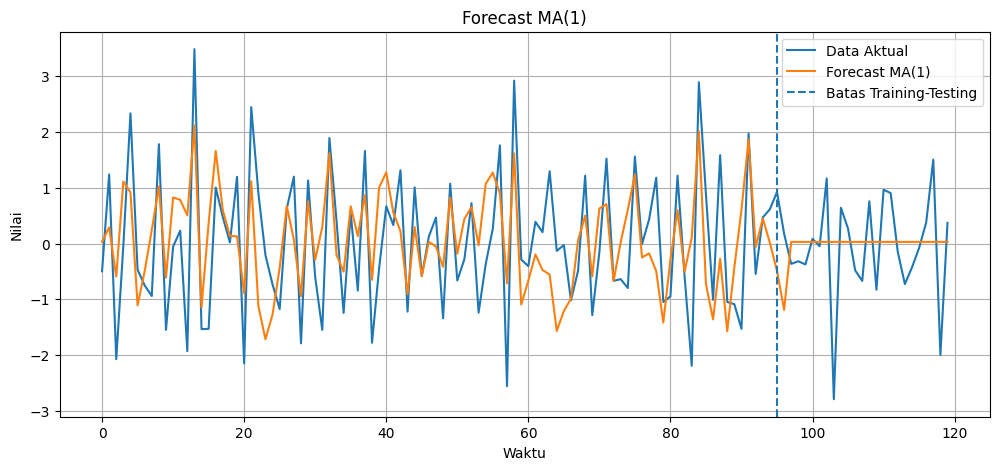

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(actual_all, label='Data Aktual')
plt.plot(forecast_all, label='Forecast MA(1)')

plt.axvline(
    x=len(train)-1,
    linestyle='--',
    label='Batas Training-Testing'
)

plt.title('Forecast MA(1)')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

### Evaluasi Model

Berdasarkan hasil evaluasi, model MA(1) menghasilkan MAPE sebesar **233,62%** pada data training dan **131,64%** pada data testing. Nilai tersebut menunjukkan kesalahan relatif yang tinggi sehingga model belum dapat dikatakan baik berdasarkan MAPE. Sementara itu, RMSE training sebesar **1,013** dan testing sebesar **0,978** menunjukkan bahwa besar kesalahan absolut relatif stabil antara data training dan testing. Tingginya MAPE kemungkinan dipengaruhi oleh adanya nilai aktual yang mendekati nol, sehingga MAPE menjadi kurang representatif untuk data ini. Oleh karena itu, evaluasi model sebaiknya juga mempertimbangkan RMSE.

# **AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$**

1\. Simulasikan deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$

In [ ]:
#====================================================
# DATA AR (2)
#====================================================

# Parameter AR(2)
n = 100
phi1 = 0.9
phi2 = -0.5

# Set seed
np.random.seed(160)

# Error
error = np.random.normal(0, 1, n)

# Inisialisasi data
data_ar2 = np.zeros(n)

# Nilai awal
data_ar2[0] = error[0]
data_ar2[1] = phi1 * data_ar2[0] + error[1]

# Bangkitkan data AR(2)
for t in range(2, n):
    data_ar2[t] = (phi1 * data_ar2[t-1] +
                   phi2 * data_ar2[t-2] +
                   error[t])

# Tampilkan data frame
df_ar2 = pd.DataFrame({
    'Waktu': np.arange(1, n+1),
    'AR2': data_ar2
})

df_ar2

,Waktu,AR2
0,1,-0.496779
1,2,0.490923
2,3,-0.816410
3,4,-1.916185
4,5,0.452178
...,...,...
95,96,2.668013
96,97,2.358049
97,98,1.041684
98,99,-0.407173


Data simulasi AR(2) terdiri atas 100 observasi yang diamati pada periode 1 hingga 100. Nilai deret AR(2) menunjukkan fluktuasi di sekitar nilai nol dan tidak memperlihatkan kecenderungan tren yang jelas. Variasi nilai antarperiode mencerminkan karakteristik proses autoregresif orde dua, yaitu nilai pada suatu periode dipengaruhi oleh nilai pada dua periode sebelumnya serta komponen error acak.

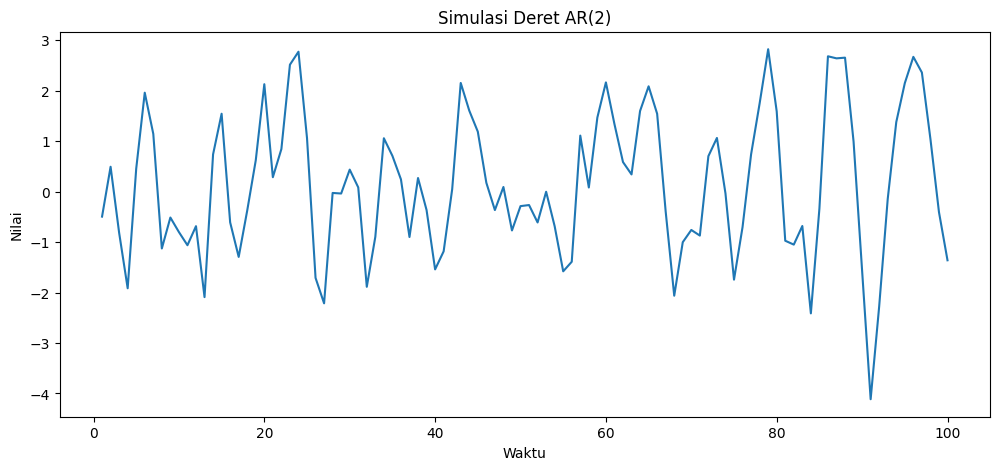

In [ ]:
#====================================================
# PLOT DERET WAKTU
#====================================================

plt.figure(figsize=(12, 5))

plt.plot(df_ar2['Waktu'], df_ar2['AR2'])

plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.title('Simulasi Deret AR(2)')
plt.show()

Berdasarkan plot deret waktu hasil simulasi AR(2), terlihat bahwa data berfluktuasi di sekitar nilai nol tanpa menunjukkan kecenderungan tren yang sistematis. Nilai pengamatan mengalami perubahan positif dan negatif sepanjang 100 periode, dengan beberapa fluktuasi yang cukup besar. Tidak terlihat pola musiman yang jelas pada deret. Secara visual, deret menunjukkan karakteristik data yang relatif stasioner dalam rata-rata, meskipun kepastian mengenai stasioneritas perlu dikonfirmasi melalui analisis lebih lanjut seperti plot ACF dan PACF.

2\. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

In [ ]:
# PEMBAGIAN DATA TRAINING DAN TESTING (80:20)
train_size = int(0.8 * len(data_ar2))

data_train = data_ar2[:train_size]
data_test = data_ar2[train_size:]

print("Jumlah data training:", len(data_train))
print("Jumlah data testing :", len(data_test))

Jumlah data training: 80
Jumlah data testing : 20


3\. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.

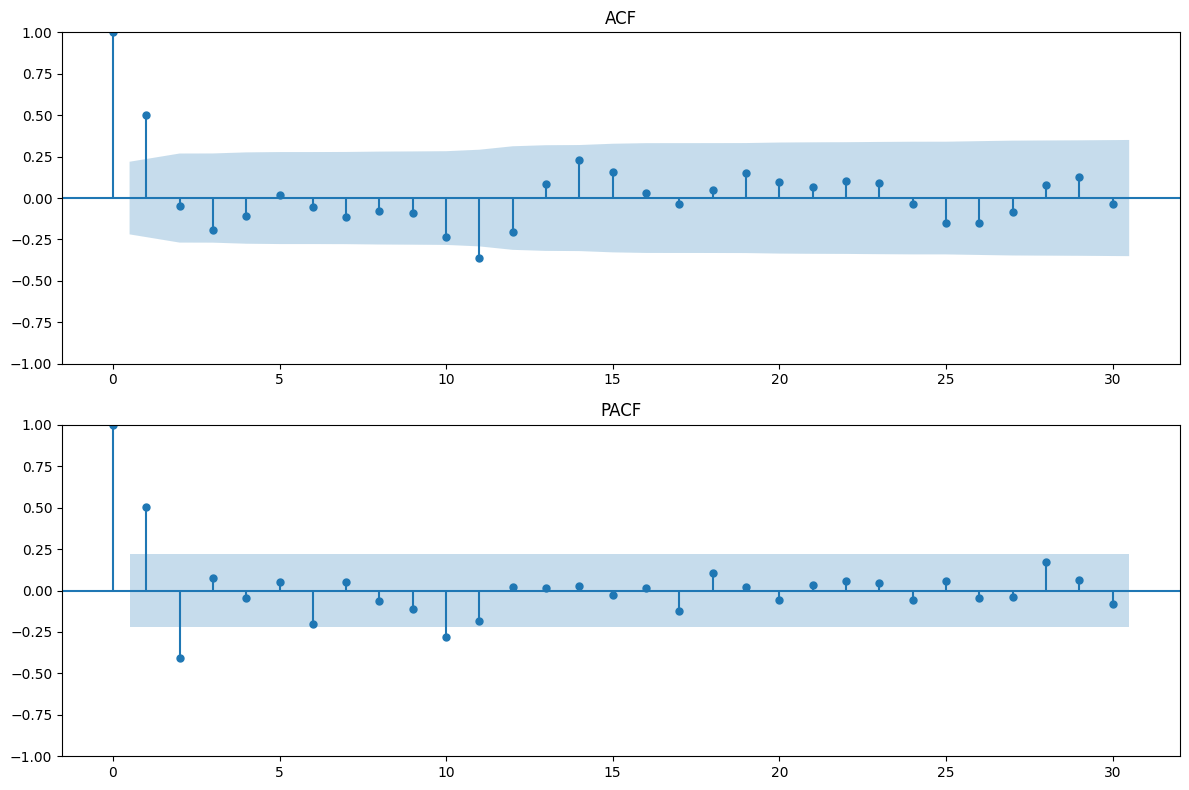

In [ ]:
#====================================================
# PLOT ACF DAN PACF DATA TRAINING
#====================================================

acf_pacf_fig(data_train, both=True, lag=30); plt.show()

Berdasarkan plot ACF, terlihat bahwa spike pada lag 1 berada di luar batas signifikansi, sedangkan pada lag-lag berikutnya nilai autokorelasi cenderung berfluktuasi di sekitar nol dan tidak menunjukkan pola cut-off yang tegas. Sementara itu, plot PACF menunjukkan spike yang signifikan pada lag 1 dan lag 2, kemudian sebagian besar nilai PACF pada lag berikutnya berada dalam batas signifikansi. Pola tersebut menunjukkan bahwa model autoregressive dengan orde 2 (AR(2)) merupakan kandidat utama.

Selain AR(2), beberapa model lain masih dapat dipertimbangkan sebagai model pembanding, yaitu AR(1) karena terdapat spike signifikan pada lag 1, AR(3) sebagai model autoregressive dengan orde yang sedikit lebih tinggi, serta MA(1) dan ARMA(1,1) karena pola ACF dan PACF juga memungkinkan adanya komponen MA. Model-model kandidat tersebut selanjutnya perlu dibandingkan berdasarkan nilai AIC dan BIC serta hasil diagnostik residual untuk menentukan model yang digunakan dalam peramalan.

In [ ]:
%%R -i data_train
# PLOT EACF DATA TRAINING
eacf(as.numeric(data_train))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o x  o  o  o 
1 x o o o o o o o o o x  o  o  o 
2 o o o o o o o o o o o  o  o  o 
3 x o o x o o o o o o o  o  o  o 
4 x o o x o o o o o o o  o  o  o 
5 o o o x o o o o o o o  o  o  o 
6 x o x x o o o o o o o  o  o  o 
7 x o o x o o o o o o o  o  o  o 


Berdasarkan hasil EACF pada data training, pola segitiga simbol o menunjukkan titik awal pada orde AR (p=2) dan orde MA (q=0). Dengan demikian, hasil EACF mengindikasikan model ARMA(2,0), yang ekuivalen dengan model AR(2). Hasil ini konsisten dengan identifikasi berdasarkan plot ACF dan PACF, sehingga AR(2) ditetapkan sebagai kandidat utama untuk tahap pengepasan model.

In [ ]:
#====================================================
# PERBANDINGAN MODEL AR, MA, DAN ARMA
#====================================================

from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Model kandidat
model_ar1 = ARIMA(data_train, order=(1,0,0)).fit()
model_ar2 = ARIMA(data_train, order=(2,0,0)).fit()
model_ar3 = ARIMA(data_train, order=(3,0,0)).fit()
model_ma1 = ARIMA(data_train, order=(0,0,1)).fit()
model_arma11 = ARIMA(data_train, order=(1,0,1)).fit()

# Tabel perbandingan
hasil_model = pd.DataFrame({
    'Model': ['AR(1)', 'AR(2)', 'AR(3)', 'MA(1)', 'ARMA(1,1)'],
    'AIC': [
        model_ar1.aic,
        model_ar2.aic,
        model_ar3.aic,
        model_ma1.aic,
        model_arma11.aic
    ],
    'BIC': [
        model_ar1.bic,
        model_ar2.bic,
        model_ar3.bic,
        model_ma1.bic,
        model_arma11.bic
    ],
    'HQIC': [
        model_ar1.hqic,
        model_ar2.hqic,
        model_ar3.hqic,
        model_ma1.hqic,
        model_arma11.hqic
    ]
})

# Urutkan berdasarkan AIC
hasil_model = hasil_model.sort_values('AIC')

print("PERBANDINGAN MODEL")
print(hasil_model.to_string(index=False))

PERBANDINGAN MODEL
    Model        AIC        BIC       HQIC
    MA(1) 230.268577 237.414657 233.133645
    AR(2) 231.365642 240.893749 235.185733
ARMA(1,1) 231.767149 241.295255 235.587239
    AR(3) 232.873127 244.783260 237.648240
    AR(1) 243.535235 250.681315 246.400303


Berdasarkan hasil perbandingan model, MA(1) menghasilkan nilai AIC, BIC, dan HQIC paling kecil, masing-masing sebesar 230,2686, 237,4147, dan 233,1365. Sementara itu, model AR(2) menghasilkan nilai AIC sebesar 231,3656, BIC sebesar 240,8937, dan HQIC sebesar 235,1857. Dengan demikian, berdasarkan kriteria informasi, MA(1) memiliki nilai kriteria yang lebih kecil dibandingkan model lainnya pada data training. Selanjutnya, pemilihan model perlu mempertimbangkan hasil diagnostik residual sebelum digunakan untuk peramalan.

In [ ]:
# MODEL AR(2)
model_ar2 = ARIMA(data_train,order=(2,0,0)).fit()
print(model_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -111.683
Date:                Wed, 23 Sep 2026   AIC                            231.366
Time:                        04:33:56   BIC                            240.894
Sample:                             0   HQIC                           235.186
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0995      0.155      0.641      0.521      -0.205       0.404
ar.L1          0.7069      0.111      6.396      0.000       0.490       0.923
ar.L2         -0.4118      0.109     -3.775      0.0

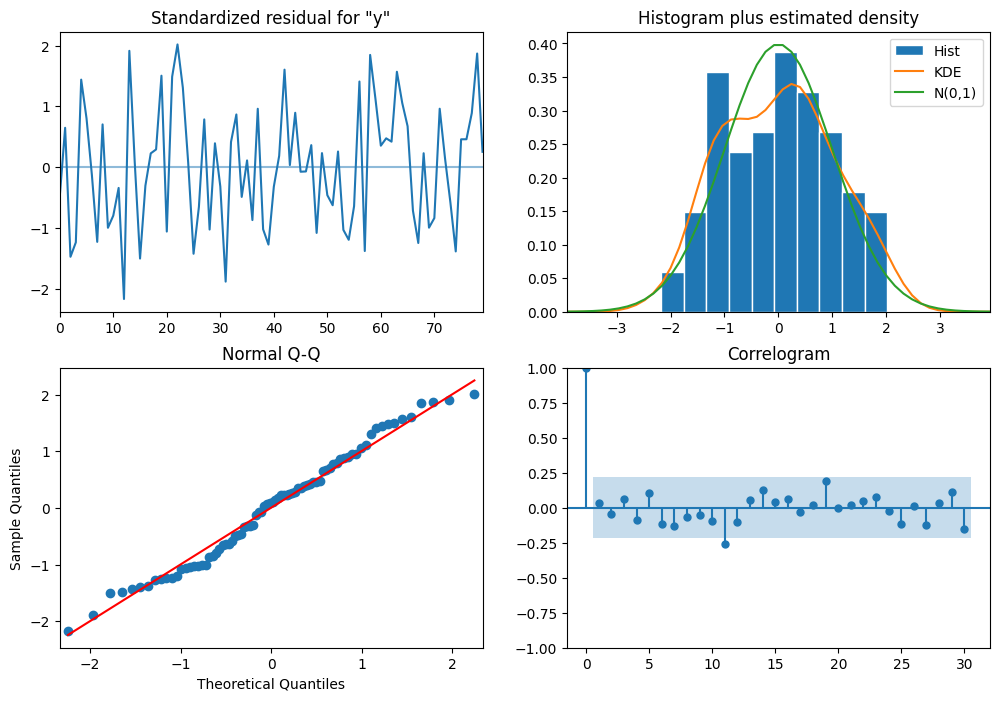

In [ ]:
#====================================================
# DIAGNOSTIK SISAAN MODEL AR(2)
#====================================================

model_ar2.plot_diagnostics(figsize=(12,8), lags=30)

plt.show()

In [ ]:
model_ar2.test_heteroskedasticity('breakvar')

array([[0.78146399, 0.52611166]])

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_ar2.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.84398121623078)

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_ar2.resid, correction=False)

(np.float64(-0.17540188275467763), np.float64(0.8607638612964248))

In [ ]:
from scipy.stats import shapiro
stat,p = shapiro(model_ar2.resid)
print(stat,p)

0.9775864986097752 0.17261432340807398


In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ar2.resid)
print(jb_stat, jb_pval)

2.386050802844284 0.30330226349554


In [ ]:
#====================================================
# UJI LJUNG-BOX
#====================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_ar2.resid,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10   6.430631   0.777880
20  20.313671   0.438468


In [ ]:
#====================================================
# Uji normalitas
#====================================================

from scipy.stats import shapiro

stat, p = shapiro(model_ar2.resid)

print("Statistik Shapiro-Wilk:", stat)
print("p-value:", p)

Statistik Shapiro-Wilk: 0.9775864986097752
p-value: 0.17261432340807398


In [ ]:
#====================================================
# Uji heteroskedastisitas
#====================================================
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(model_ar2.resid, nlags=30)

print("LM Statistic :", arch_test[0])
print("LM p-value   :", arch_test[1])

LM Statistic : 22.27163478732608
LM p-value   : 0.84398121623078


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [ ]:
#====================================================
# POIN 5: PERAMALAN
#====================================================

model_terbaik = model_ar2

In [ ]:
# Peramalan sebanyak jumlah data testing
forecast_test = model_terbaik.forecast(steps=len(data_test))

print("Hasil peramalan:")
print(forecast_test)

Hasil peramalan:
[ 0.0314172  -0.56152993 -0.33971571  0.06127138  0.2533659   0.22401225
  0.12415268  0.06565399  0.06542847  0.08936063  0.10637035  0.10853796
  0.10306504  0.09830372  0.09719203  0.09836706  0.09965548  0.10008231
  0.09985341  0.09951583]


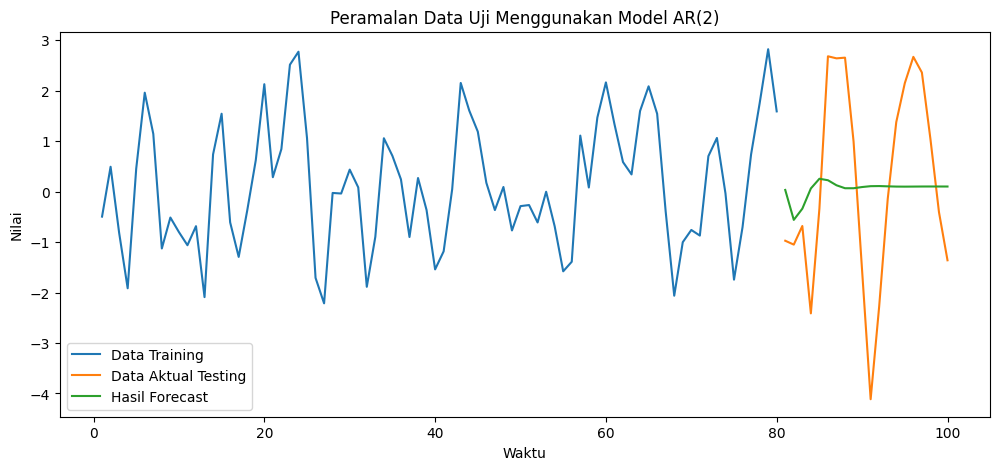

In [ ]:
#=====================================
# Plot data aktual dan hasil peramalan
#======================================

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(data_train) + 1),
    data_train,
    label='Data Training'
)

plt.plot(
    range(len(data_train) + 1, len(data_ar2) + 1),
    data_test,
    label='Data Aktual Testing'
)

plt.plot(
    range(len(data_train) + 1, len(data_ar2) + 1),
    forecast_test,
    label='Hasil Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.title('Peramalan Data Uji Menggunakan Model AR(2)')
plt.legend()
plt.show()

Berdasarkan hasil peramalan menggunakan model AR(2), terlihat bahwa data training (garis biru) menunjukkan fluktuasi yang cukup besar. Pada periode data testing, nilai aktual (garis oranye) juga mengalami fluktuasi yang cukup tinggi, sedangkan hasil forecast (garis hijau) cenderung mendekati nilai nol dan relatif stabil. Hal ini menunjukkan bahwa model AR(2) kurang mampu mengikuti perubahan dan fluktuasi aktual pada periode pengujian. Dengan demikian, secara visual terdapat perbedaan yang cukup besar antara hasil peramalan dan data aktual pada data testing.

In [ ]:
#============================================
# RMSE data uji
#============================================
from sklearn.metrics import mean_squared_error

rmse_test = np.sqrt(
    mean_squared_error(data_test, forecast_test)
)

print("RMSE Data Uji =", rmse_test)

RMSE Data Uji = 1.934481412881865


In [ ]:
#============================================
# MAPE data uji
#============================================

mape_test = np.mean(
    np.abs((data_test - forecast_test) / data_test)
) * 100

print("MAPE Data Uji =", mape_test, "%")

MAPE Data Uji = 102.08079776629697 %


In [ ]:
#======================================
# Prediksi data training
#=======================================
pred_train = model_terbaik.predict(
    start=0,
    end=len(data_train) - 1
)

pred_train

array([ 9.95082648e-02, -1.99037383e-01,  6.21756069e-01, -7.09120618e-01,
       -9.48114681e-01,  1.17892323e+00,  1.26803386e+00,  7.08239845e-02,
       -1.19757802e+00,  1.70950793e-01, -2.85189954e-01, -3.51019602e-01,
        2.31854289e-02, -1.12561440e+00,  1.45189743e+00,  8.56363769e-01,
       -9.95927354e-01, -5.93976552e-01,  3.38286065e-01,  6.62939697e-01,
        1.31780828e+00, -6.04947689e-01,  5.48596443e-01,  1.49940003e+00,
        9.93375322e-01, -3.21008434e-01, -1.57580321e+00, -7.90866472e-01,
        9.62600727e-01,  5.39135168e-02,  3.93242277e-01, -5.07399131e-02,
       -1.29746633e+00,  2.13655514e-01,  1.18560022e+00,  1.35078769e-01,
       -5.07530171e-02, -6.65655442e-01,  6.30460176e-01, -2.99702384e-01,
       -8.68738089e-01, -1.31933435e-01,  5.91025795e-01,  1.57151841e+00,
        3.17205616e-01,  2.48664222e-01, -2.95925542e-01, -2.60480502e-01,
        2.84934406e-01, -5.11751961e-01,  1.83325533e-01, -1.20819026e-05,
       -2.52545992e-01,  

In [ ]:
#======================================
#RMSE dan MAPE data training
#=======================================

rmse_train = np.sqrt(
    mean_squared_error(data_train, pred_train)
)

mape_train = np.mean(
    np.abs((data_train - pred_train) / data_train)
) * 100

print("RMSE Data Latih =", rmse_train)
print("MAPE Data Latih =", mape_train, "%")

RMSE Data Latih = 0.9747119242340602
MAPE Data Latih = 283.8554723656471 %


In [ ]:
#===========================
#Tabel hasil evaluasi
#===========================

hasil_evaluasi = pd.DataFrame({
    'Data': ['Training', 'Testing'],
    'RMSE': [rmse_train, rmse_test],
    'MAPE (%)': [mape_train, mape_test]
})

print(hasil_evaluasi)

       Data      RMSE    MAPE (%)
0  Training  0.974712  283.855472
1   Testing  1.934481  102.080798


In [ ]:
#=====================================
# MODEL MA(1)
#=====================================

model_ma1 = ARIMA(data_train, order=(0,0,1)).fit()
print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -112.134
Date:                Wed, 23 Sep 2026   AIC                            230.269
Time:                        04:33:57   BIC                            237.415
Sample:                             0   HQIC                           233.134
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1136      0.193      0.587      0.557      -0.266       0.493
ma.L1          0.7126      0.077      9.215      0.000       0.561       0.864
sigma2         0.9575      0.204      4.702      0.0

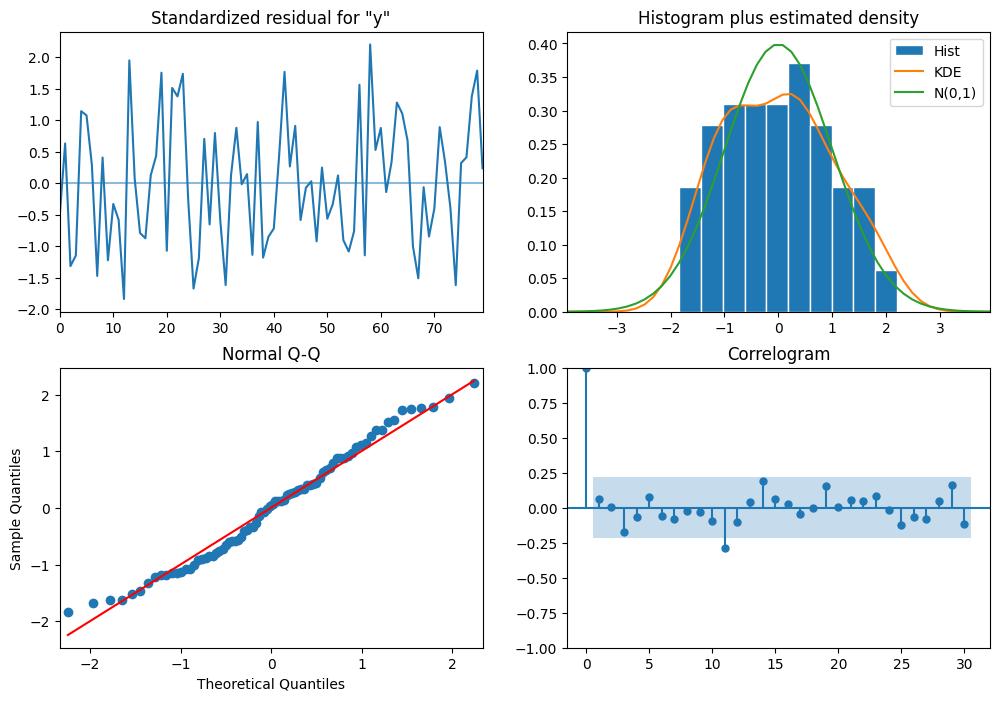

In [ ]:
#====================================================
# DIAGNOSTIK SISAAN MODEL MA(1)
#====================================================

model_ma1.plot_diagnostics(figsize=(12,8), lags=30)

plt.show()

In [ ]:
# Uji Break Variance
model_ma1.test_heteroskedasticity('breakvar')

array([[0.8262262 , 0.62342668]])

In [ ]:
from statsmodels.stats.diagnostic import het_arch

het_arch(model_ma1.resid, nlags=30)[1]


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.9056937601671599)

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp

runstest_1samp(model_ma1.resid, correction=False)

(np.float64(-0.21954869662151744), np.float64(0.8262226506047031))

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(model_ma1.resid)

print(stat, p)

0.9744897216148685 0.10982643137480086


In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ma1.resid)

print(jb_stat, jb_pval)

2.9845587001908926 0.2248595373656591


In [ ]:
#====================================================
# UJI LJUNG-BOX MA(1)
#====================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_ma1.resid,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10   5.504903   0.855005
20  21.377239   0.375235


In [ ]:
#====================================================
# UJI NORMALITAS SHAPIRO-WILK MA(1)
#====================================================

from scipy.stats import shapiro

stat, p = shapiro(model_ma1.resid)

print("Statistik Shapiro-Wilk:", stat)
print("p-value:", p)

Statistik Shapiro-Wilk: 0.9744897216148685
p-value: 0.10982643137480086


In [ ]:
#====================================================
# UJI HETEROSKEDASTISITAS MA(1)
#====================================================

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(model_ma1.resid, nlags=30)

print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F p-value:", arch_test[3])

LM Statistic: 20.40051922022632
LM p-value: 0.9056937601671599
F Statistic: 0.43650525276462165
F p-value: 0.9795155574399459


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [ ]:
#====================================================
# POIN 5: PERAMALAN MA(1)
#====================================================

model_terbaik = model_ma1

In [ ]:
# Peramalan sebanyak jumlah data testing

forecast_test = model_terbaik.forecast(
    steps=len(data_test)
)

print("Hasil peramalan:")
print(forecast_test)

Hasil peramalan:
[0.27732715 0.11359853 0.11359853 0.11359853 0.11359853 0.11359853
 0.11359853 0.11359853 0.11359853 0.11359853 0.11359853 0.11359853
 0.11359853 0.11359853 0.11359853 0.11359853 0.11359853 0.11359853
 0.11359853 0.11359853]


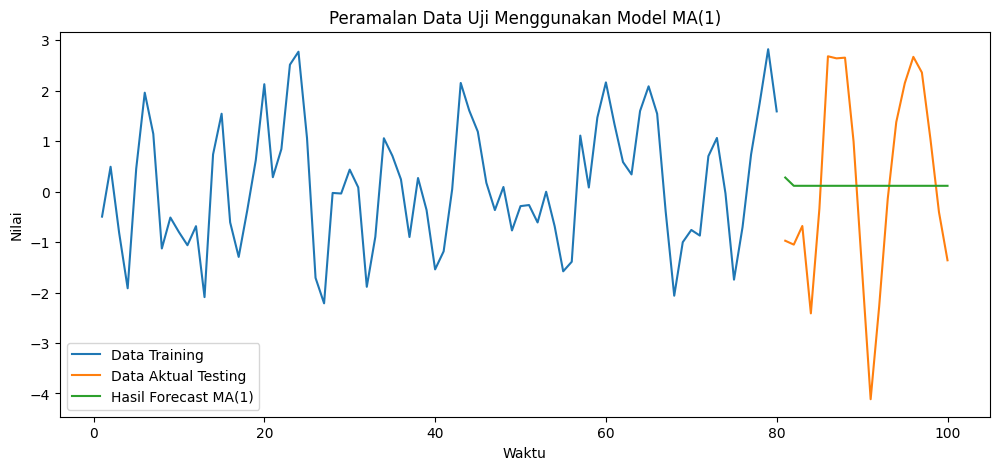

In [ ]:
#====================================================
# PLOT DATA AKTUAL DAN HASIL PERAMALAN MA(1)
#====================================================

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(data_train) + 1),
    data_train,
    label='Data Training'
)

plt.plot(
    range(len(data_train) + 1, len(data_ar2) + 1),
    data_test,
    label='Data Aktual Testing'
)

plt.plot(
    range(len(data_train) + 1, len(data_ar2) + 1),
    forecast_test,
    label='Hasil Forecast MA(1)'
)

plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.title('Peramalan Data Uji Menggunakan Model MA(1)')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_test = np.sqrt(
    mean_squared_error(data_test, forecast_test)
)

print("RMSE Data Uji =", rmse_test)

RMSE Data Uji = 1.9669673632148943


In [ ]:
mape_test = np.mean(
    np.abs((data_test - forecast_test) / data_test)
) * 100

print("MAPE Data Uji =", mape_test, "%")

MAPE Data Uji = 108.26543706755338 %


In [ ]:
model_terbaik = model_ar2
model_terbaik = model_ma1

In [ ]:
#====================================================
# PERBANDINGAN RMSE DAN MAPE
# MA(1) VS AR(2)
#====================================================

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Forecast AR(2)
forecast_ar2 = model_ar2.forecast(steps=len(data_test))

# Forecast MA(1)
forecast_ma1 = model_ma1.forecast(steps=len(data_test))

# RMSE
rmse_ar2 = np.sqrt(
    mean_squared_error(data_test, forecast_ar2)
)

rmse_ma1 = np.sqrt(
    mean_squared_error(data_test, forecast_ma1)
)

# MAPE
mape_ar2 = np.mean(
    np.abs((data_test - forecast_ar2) / data_test)
) * 100

mape_ma1 = np.mean(
    np.abs((data_test - forecast_ma1) / data_test)
) * 100

# Tabel perbandingan
hasil_forecast = pd.DataFrame({
    'Model': ['AR(2)', 'MA(1)'],
    'RMSE': [rmse_ar2, rmse_ma1],
    'MAPE (%)': [mape_ar2, mape_ma1]
})

print(hasil_forecast)

   Model      RMSE    MAPE (%)
0  AR(2)  1.934481  102.080798
1  MA(1)  1.966967  108.265437


Berdasarkan hasil evaluasi pada data testing, model AR(2) menghasilkan nilai RMSE sebesar 1,934481 dan MAPE sebesar 102,080978%, sedangkan model MA(1) menghasilkan RMSE sebesar 1,966967 dan MAPE sebesar 108,265437%. Dengan demikian, AR(2) menghasilkan nilai RMSE dan MAPE yang lebih rendah dibandingkan MA(1), sehingga pada data testing model AR(2) memberikan kesalahan peramalan yang lebih rendah. Meskipun demikian, nilai MAPE yang melebihi 100% pada kedua model menunjukkan bahwa MAPE kurang representatif untuk mengevaluasi data simulasi ini, sehingga interpretasi performa model lebih baik mempertimbangkan RMSE.

<h2> ARMA (1,1) </h2>

Kita simulasikan deret ARMA (1,1) dengan n=200 $\phi=0.4$ dan $\theta=-0.6$

In [ ]:
# Simulasi ARMA(1,1)
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
np.random.seed(160)
ar1 = np.array([1,-0.4]) # nilai parameter phi dituliskan sebagai negatif
ma1 = np.array([1,0.6]) # nilai parameter theta dituliskan sesuai konvensi statsmodels
arma_object1 = ArmaProcess(ar1,ma1)
arma1 = arma_object1.generate_sample(nsample=200)

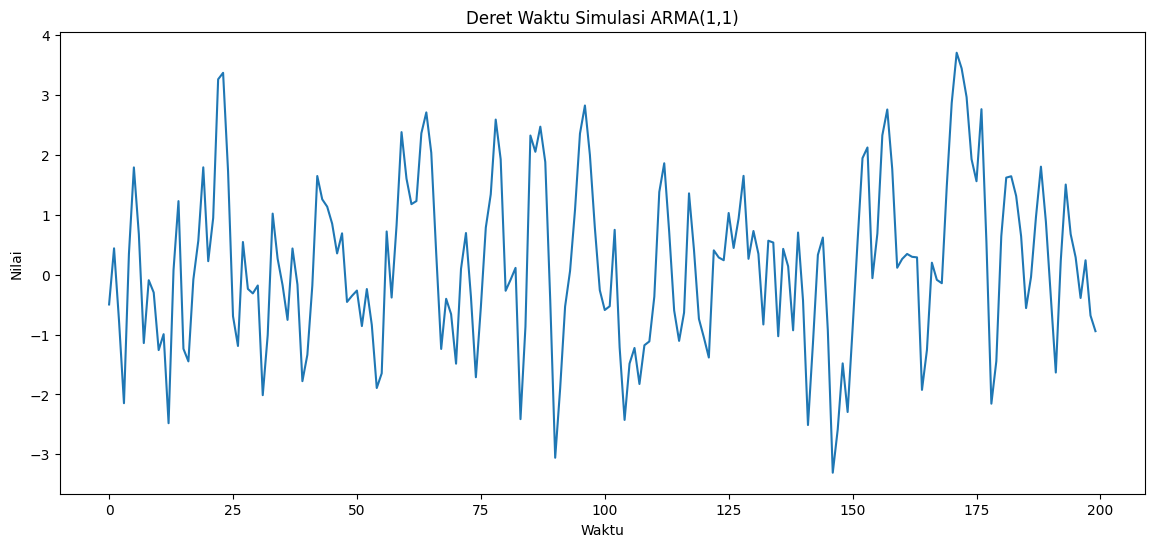

In [ ]:
# Plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(arma1)
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.title('Deret Waktu Simulasi ARMA(1,1)')
plt.show()

Berdasarkan plot, deret simulasi ARMA(1,1) berfluktuasi di sekitar nilai rata-rata yang relatif konstan. Tidak terlihat tren naik atau turun yang sistematis, dan tidak tampak pola musiman yang berulang. Variabilitas deret juga relatif stabil sepanjang periode pengamatan, meskipun terdapat beberapa nilai ekstrem secara acak.

**Pembagian Data Training dan Testing**

In [ ]:
size_train = round(0.8 * arma1.shape[0])
train, test = arma1[:size_train], arma1[size_train:]
print("Jumlah data :", len(arma1))
print("Jumlah data training :", len(train))
print("Jumlah data testing :", len(test))

Jumlah data : 200
Jumlah data training : 160
Jumlah data testing : 40


Berdasarkan hasil pembagian data, deret waktu hasil simulasi ARMA(1,1) yang terdiri atas 200 observasi dibagi menjadi data training dan data testing dengan proporsi 80%:20%. Sebanyak 160 observasi pertama digunakan sebagai data training, sedangkan 40 observasi terakhir digunakan sebagai data testing.

In [ ]:
train[:5]

array([-0.4967794 ,  0.44124506, -0.76731761, -2.14685932,  0.34822263])

In [ ]:
test[:5]

array([ 0.26316153,  0.34731822,  0.29935578,  0.29026917, -1.92405873])

Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.

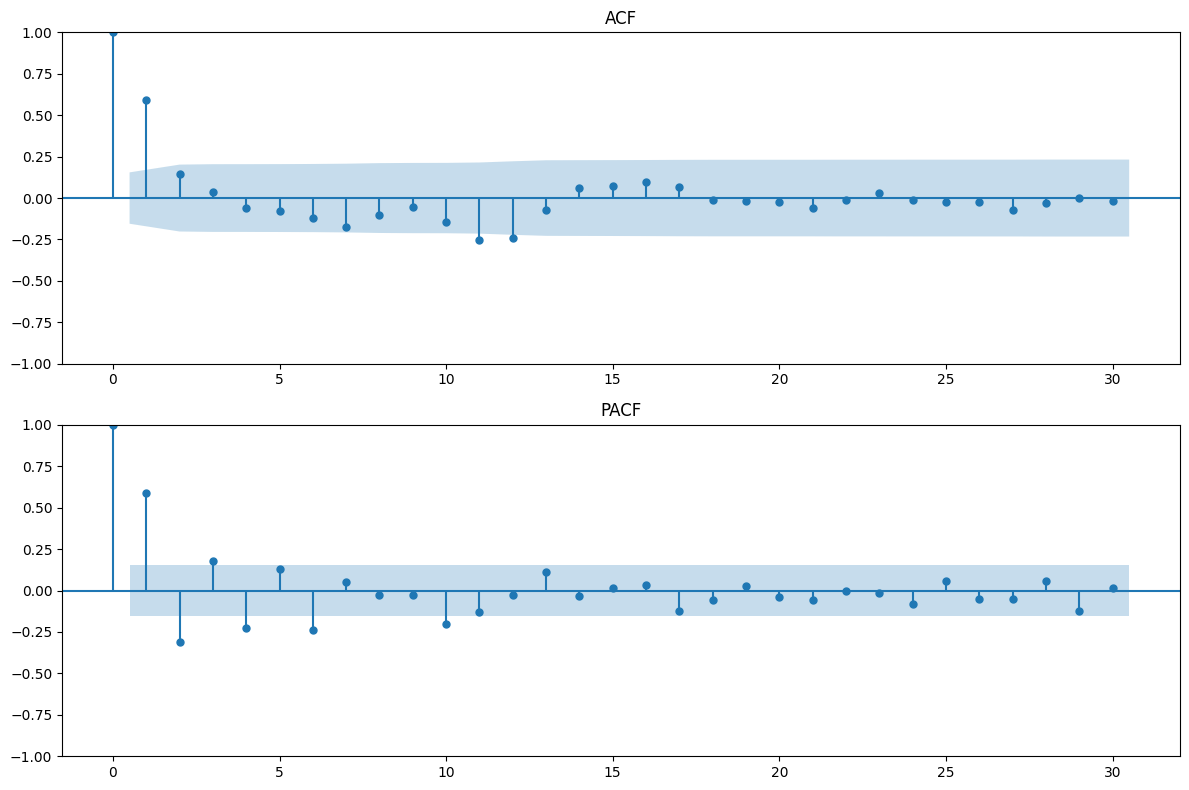

In [ ]:
# Plot ACF dan PACF data training
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
# ACF
plot_acf(train, lags=30, ax=ax[0])
ax[0].set_title("ACF")
# PACF
plot_pacf(train, lags=30, ax=ax[1], method='ywm')
ax[1].set_title("PACF")
plt.tight_layout()
plt.show()

Berdasarkan plot ACF, terlihat bahwa autokorelasi pada lag 1 signifikan, kemudian mengalami penurunan dan berfluktuasi di sekitar nol. Sementara itu, plot PACF menunjukkan spike signifikan pada lag 1 dan beberapa lag berikutnya. Kedua plot tidak menunjukkan pola cut-off yang tegas, sehingga mengindikasikan adanya komponen autoregressive (AR) dan moving average (MA). Oleh karena itu, model ARMA dipertimbangkan sebagai kandidat model untuk deret tersebut. Salah satu kandidat yang digunakan adalah ARMA(1,1).

In [ ]:
hasil_adf = adfuller(train, autolag='AIC')

print("ADF Statistic :", hasil_adf[0])
print("p-value       :", hasil_adf[1])

ADF Statistic : -5.4174502506660644
p-value       : 3.1127679998978568e-06


/tmp/ipykernel_657/737189624.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil_adf = adfuller(train, autolag='AIC')


Berdasarkan hasil uji Augmented Dickey-Fuller (ADF), diperoleh nilai statistik ADF sebesar −5,4175 dengan p-value sebesar 3,113 × 10⁻⁶. Karena p-value lebih kecil dari taraf signifikansi 5%, maka H₀ ditolak. Dengan demikian, deret pada data latih dapat dinyatakan stasioner, sehingga tidak diperlukan proses differencing. Oleh karena itu, pemodelan dapat dilakukan dalam bentuk ARMA, dengan orde model ditentukan berdasarkan hasil identifikasi ACF, PACF, dan EACF.

In [ ]:
%%R -i train
#membuat plot EACF
eacf(as.numeric(train))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o x o o o x  x  o  o 
1 x o o o o o o o o o o  x  o  o 
2 x o x o o o x o o o o  x  o  o 
3 x x o o o o o o o o o  x  o  o 
4 x x o o x o o o o o o  o  o  o 
5 x x o x x o o o o o o  o  o  o 
6 x o x x x x o o o o o  o  o  o 
7 x o o x o x o o o o o  o  o  o 


Berdasarkan hasil EACF pada data latih, terlihat pola segitiga nilai o yang mengarah pada orde (p=1) dan (q=1). Hal ini menunjukkan bahwa model yang diidentifikasi dari EACF adalah ARMA(1,1). Hasil tersebut juga konsisten dengan pola ACF dan PACF yang menunjukkan adanya komponen autoregressive dan moving average. Oleh karena itu, ARMA(1,1) digunakan sebagai kandidat model untuk tahap pengepasan.

In [ ]:
# Model ARMA(1,1)
model_arma11 = ARIMA(train, order=(1,0,1)).fit()
print(model_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -222.401
Date:                Wed, 23 Sep 2026   AIC                            452.802
Time:                        04:33:59   BIC                            465.103
Sample:                             0   HQIC                           457.797
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0729      0.165      0.441      0.659      -0.251       0.397
ar.L1          0.1653      0.092      1.797      0.072      -0.015       0.346
ma.L1          0.7985      0.056     14.158      0.0

Berdasarkan hasil pengepasan model ARMA(1,1) pada 160 data latih, diperoleh estimasi parameter AR(1) sebesar 0,1653 dan MA(1) sebesar 0,7985. Parameter MA(1) signifikan pada taraf 5%, sedangkan parameter AR(1) belum signifikan. Hasil uji Ljung-Box menghasilkan p-value sebesar 0,97 > 0,05, sehingga tidak terdapat bukti adanya autokorelasi pada sisaan. Dengan demikian, model ARMA(1,1) layak digunakan sebagai model kandidat untuk deret simulasi. Selanjutnya, model perlu dibandingkan dengan model yang lebih kompleks melalui overfitting serta kriteria AIC dan BIC untuk menentukan model akhir.

**pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC**

Diagnostik sisaan model ARMA(1,1)

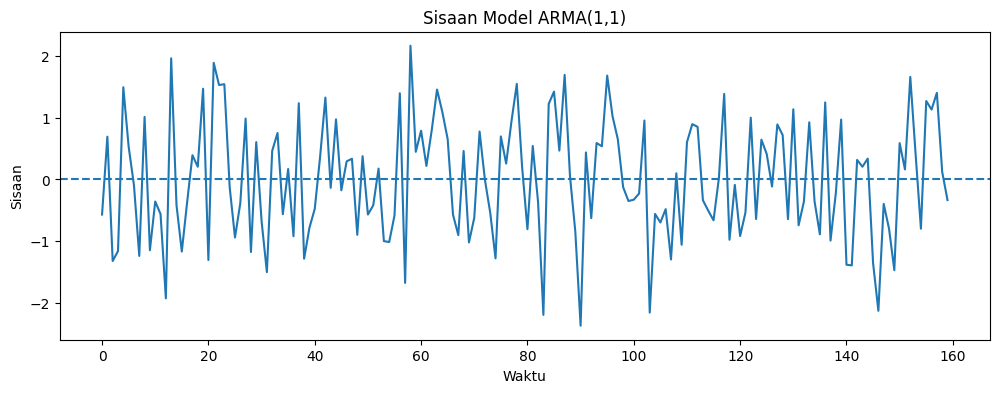

In [ ]:
import matplotlib.pyplot as plt

residual = model_arma11.resid

plt.figure(figsize=(12,4))
plt.plot(residual)
plt.axhline(0, linestyle='--')
plt.title("Sisaan Model ARMA(1,1)")
plt.xlabel("Waktu")
plt.ylabel("Sisaan")
plt.show()

Berdasarkan plot sisaan model ARMA(1,1), sisaan berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis, tren, maupun perubahan varians yang jelas. Nilai sisaan berada pada sisi positif dan negatif secara relatif seimbang sepanjang periode pengamatan. Hal ini menunjukkan bahwa tidak terdapat pola yang tersisa pada sisaan dan model telah mampu menangkap struktur utama deret waktu.

<Figure size 1200x400 with 0 Axes>

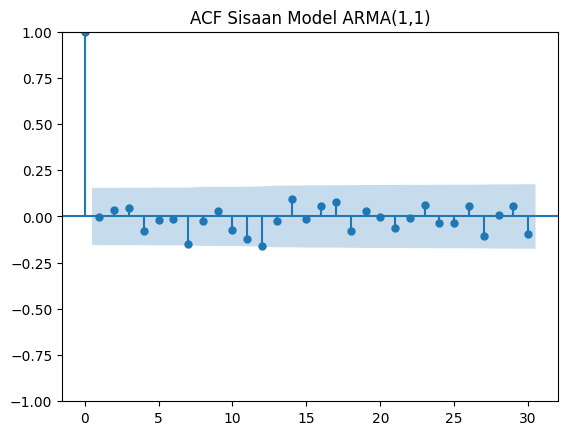

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,4))
plot_acf(residual, lags=30)
plt.title("ACF Sisaan Model ARMA(1,1)")
plt.show()

Berdasarkan plot ACF sisaan model ARMA(1,1), hampir seluruh nilai autokorelasi pada lag 1 hingga lag 30 berada dalam batas interval kepercayaan 95%. Tidak terdapat spike yang menunjukkan autokorelasi signifikan pada sisaan. Hal ini menunjukkan bahwa sisaan model ARMA(1,1) tidak memiliki autokorelasi yang berarti dan telah mendekati karakteristik white noise. Dengan demikian, model ARMA(1,1) telah mampu menangkap pola ketergantungan dalam data dengan baik.

In [ ]:
#Uji Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box = acorr_ljungbox(
    residual,
    lags=[10,20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10   6.762234   0.747685
20  18.379111   0.562450


Berdasarkan hasil uji Ljung-Box, diperoleh p-value sebesar 0,7477 pada lag 10 dan 0,5625 pada lag 20. Kedua nilai tersebut lebih besar dari taraf signifikansi 5%, sehingga H₀ tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada sisaan model ARMA(1,1). Hasil ini menunjukkan bahwa sisaan telah memenuhi asumsi tidak adanya autokorelasi.

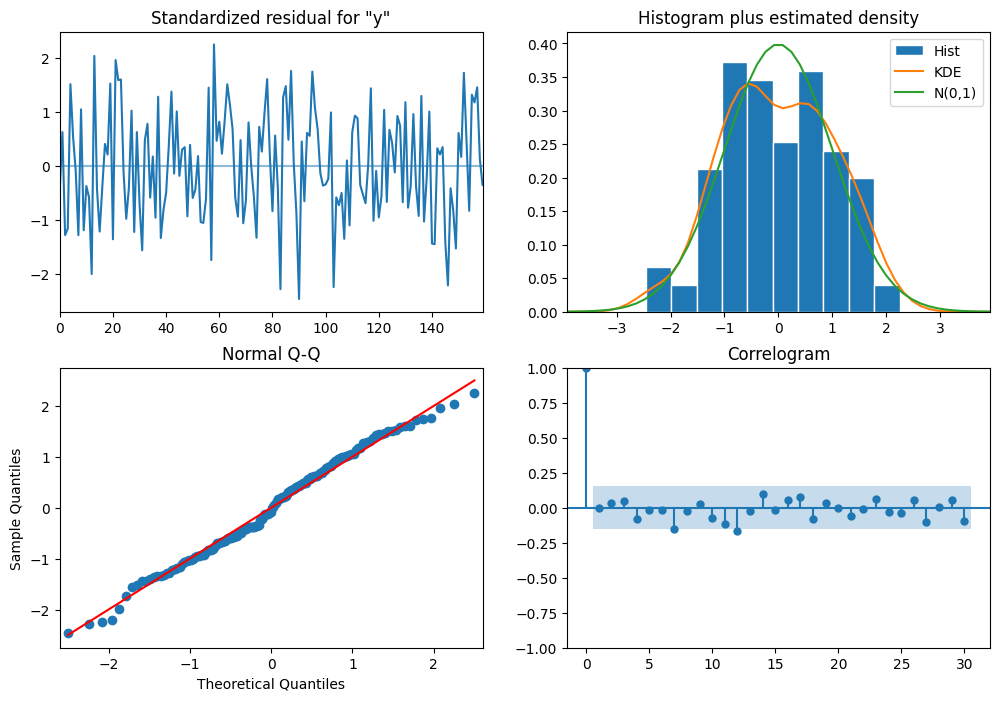

In [ ]:
# Analisis Sisaan Model ARMA(1,1)
model_arma11.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

Berdasarkan hasil diagnostik sisaan model ARMA(1,1), sisaan terstandarisasi berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis. Histogram sisaan menunjukkan distribusi yang cukup mendekati normal, sedangkan sebagian besar titik pada Normal Q-Q Plot berada di sekitar garis diagonal meskipun terdapat sedikit penyimpangan pada bagian ekor. Pada correlogram, sebagian besar nilai autokorelasi sisaan berada dalam batas interval kepercayaan. Hal ini menunjukkan bahwa sisaan model ARMA(1,1) tidak menunjukkan pola autokorelasi yang signifikan dan telah mendekati karakteristik white noise. Dengan demikian, model ARMA(1,1) telah mampu menangkap struktur ketergantungan pada data dengan baik.

In [ ]:
model_arma11.test_heteroskedasticity('breakvar')

array([[0.88237762, 0.65039866]])

In [ ]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_arma11.resid, nlags=30)[1]

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


np.float64(0.5205844143201483)

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(model_arma11.resid)
print(stat, p)

0.9867623117867843 0.1337948415666551


In [ ]:
from scipy.stats import jarque_bera
jb_stat, jb_pval = jarque_bera(model_arma11.resid)
print(jb_stat, jb_pval)

2.8407883891055437 0.24161875332567115


In [ ]:
# Uji normalitas
from scipy.stats import shapiro
stat, p = shapiro(model_arma11.resid)
print("Statistik Shapiro-Wilk:", stat)
print("p-value:", p)

Statistik Shapiro-Wilk: 0.9867623117867843
p-value: 0.1337948415666551


In [ ]:
# Uji heteroskedastisitas
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(model_arma11.resid, nlags=30)
print("LM Statistic :", arch_test[0])
print("LM p-value   :", arch_test[1])

LM Statistic : 28.94315572404124
LM p-value   : 0.5205844143201483


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Model kandidat
model_ar1 = ARIMA(train, order=(1,0,0)).fit()
model_ma1 = ARIMA(train, order=(0,0,1)).fit()
model_arma11 = ARIMA(train, order=(1,0,1)).fit()

# Model overfitting
model_arma21 = ARIMA(train, order=(2,0,1)).fit()
model_arma12 = ARIMA(train, order=(1,0,2)).fit()
model_arma22 = ARIMA(train, order=(2,0,2)).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [ ]:
import pandas as pd

hasil_model = pd.DataFrame({
    "Model": [
        "AR(1)",
        "MA(1)",
        "ARMA(1,1)",
        "ARMA(2,1)",
        "ARMA(1,2)",
        "ARMA(2,2)"
    ],
    "AIC": [
        model_ar1.aic,
        model_ma1.aic,
        model_arma11.aic,
        model_arma21.aic,
        model_arma12.aic,
        model_arma22.aic
    ],
    "BIC": [
        model_ar1.bic,
        model_ma1.bic,
        model_arma11.bic,
        model_arma21.bic,
        model_arma12.bic,
        model_arma22.bic
    ]
})

print(hasil_model)

       Model         AIC         BIC
0      AR(1)  489.407850  498.633372
1      MA(1)  453.986929  463.212450
2  ARMA(1,1)  452.801964  465.102660
3  ARMA(2,1)  454.433719  469.809588
4  ARMA(1,2)  454.509515  469.885384
5  ARMA(2,2)  456.429270  474.880313


Berdasarkan hasil perbandingan nilai AIC dan BIC, model ARMA(1,1) memiliki nilai AIC terendah sebesar 452,8020, sedangkan model MA(1) memiliki nilai BIC terendah sebesar 463,2125. Dengan demikian, AIC mengindikasikan ARMA(1,1) sebagai model yang lebih sesuai, sedangkan BIC mengindikasikan MA(1). Model ARMA(2,1), ARMA(1,2), dan ARMA(2,2) memiliki nilai AIC dan BIC yang lebih besar dibandingkan ARMA(1,1), sehingga penambahan orde AR atau MA tidak memberikan perbaikan berdasarkan kriteria tersebut.
Selanjutnya, model ARMA(1,1) digunakan untuk peramalan karena model tersebut memiliki nilai AIC terendah dan sesuai dengan hasil identifikasi ACF, PACF, dan EACF yang menunjukkan adanya komponen AR dan MA. Pemilihan model juga mempertimbangkan hasil diagnostik sisaan.

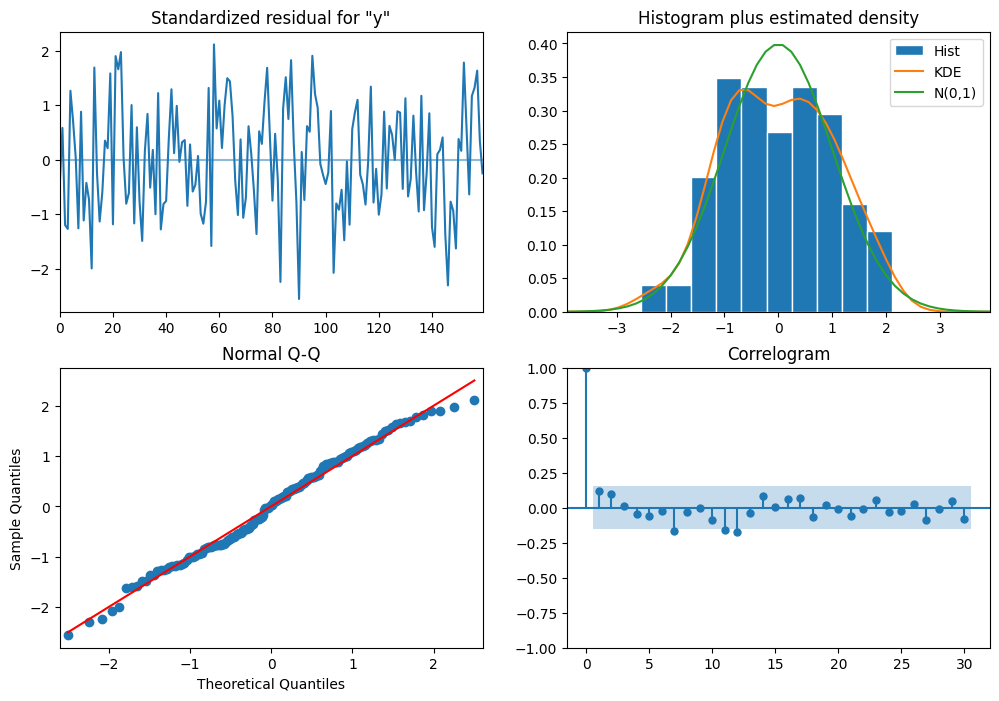

In [ ]:
model_ma1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

Berdasarkan hasil diagnostik sisaan model MA(1), sisaan terstandarisasi berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis. Histogram sisaan menunjukkan distribusi yang cukup mendekati normal, sedangkan sebagian besar titik pada Normal Q-Q Plot berada di sekitar garis diagonal meskipun terdapat sedikit penyimpangan pada bagian ekor. Pada correlogram, sebagian besar autokorelasi sisaan berada dalam batas interval kepercayaan. Hal ini menunjukkan bahwa sisaan model MA(1) tidak menunjukkan autokorelasi yang signifikan dan telah mendekati karakteristik white noise.

In [ ]:
ljung_box_ma1 = acorr_ljungbox(
    model_ma1.resid,
    lags=[10,20],
    return_df=True
)

print(ljung_box_ma1)

      lb_stat  lb_pvalue
10  10.831534   0.370793
20  24.171468   0.234982


Hasil diagnostik menunjukkan bahwa sisaan model ARMA(1,1) tidak memiliki autokorelasi yang signifikan. ARMA(1,1) memiliki AIC terendah sebesar 452,802, sedangkan BIC terendah diperoleh MA(1) sebesar 463,212. Meskipun demikian, hasil ACF, PACF, dan EACF mengindikasikan adanya komponen AR dan MA, sehingga ARMA(1,1) dipilih sebagai model untuk tahap peramalan.

In [ ]:
# Peramalan menggunakan model terbaik ARMA(1,1)
prediksi_test = model_arma11.get_forecast(40).summary_frame(alpha=0.05)
prediksi_test.head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,-0.186972,0.967566,-2.083365,1.709422
1,0.029944,1.343816,-2.603887,2.663774
2,0.065796,1.352626,-2.585304,2.716895
3,0.071721,1.352866,-2.579848,2.723291
4,0.072701,1.352873,-2.578881,2.724283


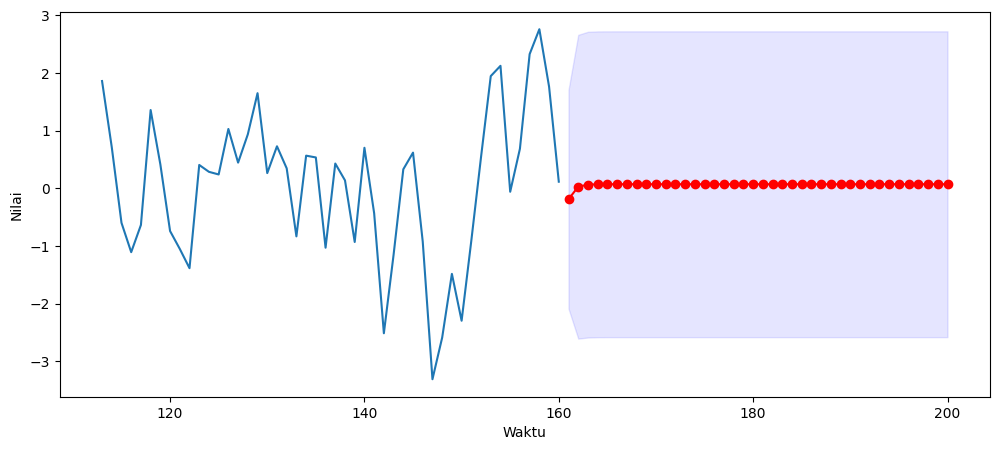

In [ ]:
plt.figure(figsize=(12,5))
# 48 observasi terakhir data training: periode 113-160
plt.plot(range(113,161), train[-48:])
# Hasil prediksi data testing: periode 161-200
plt.plot(range(161,201), prediksi_test['mean'], '-or')
# Interval kepercayaan 95%
plt.fill_between(
    range(161,201),
    prediksi_test['mean_ci_lower'],
    prediksi_test['mean_ci_upper'],
    color='b',
    alpha=.1
)
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Berdasarkan hasil peramalan model ARMA(1,1), nilai ramalan pada periode awal data uji berada di sekitar −0,2 dan kemudian bergerak mendekati nilai rata-rata deret, yaitu sekitar 0. Selanjutnya, hasil ramalan relatif konstan hingga akhir periode peramalan. Interval kepercayaan 95% semakin melebar pada periode peramalan yang lebih jauh, yang menunjukkan meningkatnya ketidakpastian hasil ramalan. Pola ramalan yang mendekati nilai rata-rata merupakan karakteristik peramalan jangka panjang pada model ARMA, karena pengaruh observasi masa lalu semakin berkurang seiring bertambahnya horizon peramalan.

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np
# Prediksi/fitted value data training
prediksi_train = model_arma11.fittedvalues
# MAPE training
mape_train = mean_absolute_percentage_error(
    train,
    prediksi_train
) * 100
# RMSE training
rmse_train = np.sqrt(
    mean_squared_error(
        train,
        prediksi_train))
print('MAPE Training :', mape_train, '%')
print('RMSE Training :', rmse_train)

MAPE Training : 159.91939580836183 %
RMSE Training : 0.9700330770617677


In [ ]:
# Prediksi data testing
prediksi_test_mean = prediksi_test['mean']

# MAPE testing
mape_test = mean_absolute_percentage_error(
    test,
    prediksi_test_mean
) * 100

# RMSE testing
rmse_test = np.sqrt(
    mean_squared_error(
        test,
        prediksi_test_mean
    )
)

print('MAPE Testing :', mape_test, '%')
print('RMSE Testing :', rmse_test)

MAPE Testing : 105.08810885708706 %
RMSE Testing : 1.4905247915770798


erdasarkan hasil evaluasi, model ARMA(1,1) menghasilkan RMSE sebesar 0,9700 pada data training dan 1,4905 pada data testing. Nilai RMSE yang lebih besar pada data testing menunjukkan bahwa kesalahan peramalan meningkat ketika model diterapkan pada data yang belum digunakan dalam proses pembentukan model. Sementara itu, diperoleh MAPE sebesar 159,92% pada data training dan 105,09% pada data testing. Nilai MAPE yang besar perlu diinterpretasikan secara hati-hati karena data simulasi ARMA dapat memiliki nilai aktual yang mendekati nol, sehingga menyebabkan MAPE menjadi besar. Oleh karena itu, RMSE lebih relevan digunakan untuk mengevaluasi kesalahan peramalan pada data simulasi ini. Secara keseluruhan, model ARMA(1,1) telah memenuhi diagnostik sisaan dan mampu menangkap struktur ketergantungan pada data, tetapi akurasi peramalan pada data uji masih menunjukkan adanya kesalahan yang relatif lebih besar.